In [19]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [20]:
# Configuration and paths
mac = 20
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

abs_phenotypes = False

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, core_promoter
# ============================================================
variant_class = 'intron'
exclude_clinvar = False  # Independent toggle: exclude ClinVar-annotated variants

# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/config_variant_classes.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']
selected_categories = vc['tool_categories']
x_label = f"Top N {vc['x_label']} variants"

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Exclude ClinVar: {exclude_clinvar}")
print(f"  Categories: {selected_categories}")
print(f"  X-label: {x_label}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_pheno.yaml" 

with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

# Build label/color maps for best-tissue and baseline annotations
# Best-tissue annotations get distinct colors; baselines use their config colors
baseline_color_map = dict(zip(
    anno_config_df['annotation'].to_list(),
    anno_config_df['color'].to_list(),
))
baseline_label_map = dict(zip(
    anno_config_df['annotation'].to_list(),
    anno_config_df['label'].to_list(),
))

best_tissue_color_map = {
    'best_tissue_corr':          '#2ca02c',   # green
    'best_tissue_zscore_k1000':  '#d62728',   # red
    'best_tissue_zscore_k10000': '#9467bd',   # purple
}
best_tissue_label_map = {
    'best_tissue_corr':          'Best tissue\n(corr)',
    'best_tissue_zscore_k1000':  'Best tissue\n(top-1k z)',
    'best_tissue_zscore_k10000': 'Best tissue\n(top-10k z)',
}

# Combined maps: best-tissue entries + baseline entries
color_map = {**best_tissue_color_map, **baseline_color_map}
label_map = {**best_tissue_label_map, **baseline_label_map}

anno_config_df

Variant class: intron
  Filters: ["(pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)", "pl.col('consequence_intron_variant') == True"]
  Exclude ClinVar: False
  Categories: ['splicing']
  X-label: Top N Intronic variants


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1


In [21]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

# CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
CORR_FILE = "regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per_correlations.parquet"
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per_correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000084674""","""ldl_direct_int""",2.2543e-301,-0.12678,0.12678,-1.0
"""ENSG00000167701""","""alanine_aminotransferase_int""",1.2234e-144,-0.106424,0.106424,-1.0
"""ENSG00000105610""","""mean_corpuscular_haemoglobin_i…",9.8993e-24,-0.100921,0.100921,-1.0
"""ENSG00000141505""","""alkaline_phosphatase_int""",8.4146e-35,0.089171,0.089171,1.0
"""ENSG00000101162""","""platelet_distribution_width_in…",1.5335e-83,0.08869,0.08869,1.0
…,…,…,…,…,…
"""ENSG00000115977""","""sitting_height_int""",0.021257,-0.001496,0.001496,-1.0
"""ENSG00000119574""","""standing_height_int""",0.025535,-0.001317,0.001317,-1.0
"""ENSG00000115325""","""platelet_distribution_width_in…",0.01277,-0.001204,0.001204,-1.0


In [22]:
# new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
# new_anno_filename = "ukbbgym_TSS_promoter_enhancer_TF_variants_all_260218_0_ukbbgym.parquet"
# !dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

# new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

# new_anno_df = pl.scan_parquet(new_anno_local)
# # rna_cols = [c for c in new_anno_df.collect_schema().names() if c.startswith('RNA:')]
# # 89 GTEx tissue tracks:
# tissue_cols = ['RNA:adipose_tissue_7522', 'RNA:adipose_tissue_7523', 'RNA:adipose_tissue_7524', 'RNA:adrenal_gland_7525', 'RNA:adrenal_gland_7526', 'RNA:adrenal_gland_7527', 'RNA:bladder_7528', 'RNA:bladder_7529', 'RNA:bladder_7530', 'RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533', 'RNA:blood_vessel_7534', 'RNA:blood_vessel_7535', 'RNA:blood_vessel_7536', 'RNA:bone_marrow_7537', 'RNA:bone_marrow_7538', 'RNA:brain_7539', 'RNA:brain_7540', 'RNA:brain_7541', 'RNA:breast_7542', 'RNA:breast_7543', 'RNA:breast_7544', 'RNA:cervix_uteri_7545', 'RNA:cervix_uteri_7546', 'RNA:cervix_uteri_7547', 'RNA:colon_7548', 'RNA:colon_7549', 'RNA:colon_7550', 'RNA:esophagus_7551', 'RNA:esophagus_7552', 'RNA:esophagus_7553', 'RNA:fallopian_tube_7554', 'RNA:fallopian_tube_7555', 'RNA:fallopian_tube_7556', 'RNA:heart_7557', 'RNA:heart_7558', 'RNA:heart_7559', 'RNA:kidney_7560', 'RNA:kidney_7561', 'RNA:kidney_7562', 'RNA:liver_7563', 'RNA:liver_7564', 'RNA:liver_7565', 'RNA:lung_7566', 'RNA:lung_7567', 'RNA:lung_7568', 'RNA:muscle_7569', 'RNA:muscle_7570', 'RNA:muscle_7571', 'RNA:nerve_7572', 'RNA:nerve_7573', 'RNA:ovary_7574', 'RNA:ovary_7575', 'RNA:ovary_7576', 'RNA:pancreas_7577', 'RNA:pancreas_7578', 'RNA:pancreas_7579', 'RNA:pituitary_7580', 'RNA:pituitary_7581', 'RNA:pituitary_7582', 'RNA:prostate_7583', 'RNA:prostate_7584', 'RNA:prostate_7585', 'RNA:salivary_gland_7586', 'RNA:salivary_gland_7587', 'RNA:salivary_gland_7588', 'RNA:skin_7589', 'RNA:skin_7590', 'RNA:skin_7591', 'RNA:small_intestine_7592', 'RNA:small_intestine_7593', 'RNA:small_intestine_7594', 'RNA:spleen_7595', 'RNA:spleen_7596', 'RNA:spleen_7597', 'RNA:stomach_7598', 'RNA:stomach_7599', 'RNA:stomach_7600', 'RNA:testis_7601', 'RNA:testis_7602', 'RNA:thyroid_7603', 'RNA:thyroid_7604', 'RNA:thyroid_7605', 'RNA:uterus_7606', 'RNA:uterus_7607', 'RNA:vagina_7608', 'RNA:vagina_7609', 'RNA:vagina_7610']

# new_anno_df = (
#     new_anno_df
#     .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
#     .with_columns(
#         fz_all_min = pl.min_horizontal(cs.starts_with('RNA:')),
#         fz_gtex_min = pl.min_horizontal(tissue_cols),
#     )
#     .select(['id', 'region', 'fz_all_min', 'fz_gtex_min'] + tissue_cols)
#     .collect()
# )

# new_anno_df

In [23]:
new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/absplice2/"
new_anno_filename = "absplice2_all_tissues_qced_maf1e-3_loftee_olink_genes_EURunrelated.parquet"
!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = pl.scan_parquet(new_anno_local)
id_cols = ['id', 'region']
model_cols = ['pangolin_score', 'gain_score', 'loss_score', 'delta_score', 'AbSplice_DNA_max', 'AbSplice2_max']
tissue_cols = [c for c in new_anno_df.collect_schema().names() if c not in id_cols + model_cols]

new_anno_df = (
    new_anno_df
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .rename({'AbSplice2_max': 'absplice2_max'})
    .select(['id', 'region'] + tissue_cols)
    .collect()
)

new_anno_df

Error: path "/home/dnanexus/data_dir/absplice2_all_tissues_qced_maf1e-3_loftee
_olink_genes_EURunrelated.parquet" already exists but -f/--overwrite was not
set


/tmp/ipykernel_467497/2279316781.py:17: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,Adipose_Subcutaneous,Adipose_Visceral_Omentum,Adrenal_Gland,Artery_Aorta,Artery_Coronary,Artery_Tibial,Brain_Amygdala,Brain_Anterior_cingulate_cortex_BA24,Brain_Caudate_basal_ganglia,Brain_Cerebellar_Hemisphere,Brain_Cerebellum,Brain_Cortex,Brain_Frontal_Cortex_BA9,Brain_Hippocampus,Brain_Hypothalamus,Brain_Nucleus_accumbens_basal_ganglia,Brain_Putamen_basal_ganglia,Brain_Spinal_cord_cervical_c_1,Brain_Substantia_nigra,Breast_Mammary_Tissue,Cells_Cultured_fibroblasts,Cells_EBV_transformed_lymphocytes,Colon_Sigmoid,Colon_Transverse,Esophagus_Gastroesophageal_Junction,Esophagus_Mucosa,Esophagus_Muscularis,Heart_Atrial_Appendage,Heart_Left_Ventricle,Kidney_Cortex,Liver,Lung,Minor_Salivary_Gland,Muscle_Skeletal,Nerve_Tibial,Ovary,Pancreas,Pituitary,Prostate,Skin_Not_Sun_Exposed_Suprapubic,Skin_Sun_Exposed_Lower_leg,Small_Intestine_Terminal_Ileum,Spleen,Stomach,Testis,Thyroid,Uterus,Vagina,Whole_Blood
str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""chr1:23030468:G:A""","""ENSG00000004487""",0.189927,0.140164,0.27282,0.12165,0.134557,0.155316,0.032831,0.045908,0.045908,0.270387,0.134368,0.076864,0.064937,0.024995,0.031051,0.045908,0.024995,0.021332,0.016968,0.260917,0.367348,0.39207,0.263824,0.271656,0.214293,0.263422,0.259918,0.093163,0.045908,0.086239,0.013015,0.12165,0.298218,0.238264,0.171256,0.325435,0.089722,0.264669,0.12165,0.184847,0.260917,0.242782,0.108396,0.134557,0.392535,0.155316,0.323268,0.263422,0.009038
"""chr1:23030469:G:T""","""ENSG00000004487""",0.123058,0.070586,0.206485,0.067544,0.067544,0.100702,0.013514,0.044311,0.044311,0.204478,0.14346,0.078376,0.063664,0.023142,0.029961,0.044311,0.023142,0.019768,0.019199,0.117723,0.352757,0.368226,0.141136,0.205916,0.159397,0.140595,0.132721,0.062441,0.044311,0.033002,0.007715,0.067544,0.196847,0.246787,0.072693,0.148319,0.042111,0.135573,0.07768,0.119503,0.117723,0.141664,0.049003,0.0644,0.098956,0.100702,0.148201,0.140595,0.011225
"""chr1:23050521:G:T""","""ENSG00000004487""",0.384782,0.397072,0.421201,0.289852,0.289852,0.316137,0.115338,0.176561,0.160531,0.413079,0.330085,0.282703,0.273709,0.107069,0.183803,0.170659,0.104581,0.105168,0.107208,0.413079,0.466022,0.464871,0.431175,0.413079,0.318324,0.413079,0.316137,0.234668,0.169505,0.25273,0.048582,0.326766,0.4388,0.421153,0.419727,0.551425,0.302816,0.484035,0.433599,0.323069,0.406635,0.413079,0.28803,0.294592,0.464871,0.419147,0.52653,0.519133,0.046334
"""chr1:23055930:A:G""","""ENSG00000004487""",0.533809,0.42966,0.544086,0.401072,0.404692,0.431253,0.164404,0.330151,0.269739,0.544086,0.453245,0.40101,0.401072,0.164404,0.334635,0.334174,0.158858,0.164404,0.150933,0.537147,0.582388,0.580589,0.536308,0.536308,0.527453,0.536308,0.527453,0.334635,0.269739,0.336916,0.08456,0.407176,0.565278,0.544676,0.462328,0.566009,0.400842,0.544676,0.431253,0.529203,0.536308,0.537147,0.401072,0.407404,0.581516,0.431253,0.550494,0.544134,0.05514
"""chr1:23057570:G:A""","""ENSG00000004487""",0.339377,0.325944,0.350245,0.318524,0.325141,0.339248,0.201578,0.220128,0.220291,0.350245,0.340647,0.325141,0.324619,0.179492,0.220128,0.234158,0.201578,0.177688,0.178677,0.348216,0.345378,0.339658,0.348216,0.350245,0.339377,0.350245,0.339377,0.234158,0.224029,0.307551,0.089884,0.329438,0.347185,0.350245,0.339377,0.347268,0.317381,0.350245,0.339248,0.339377,0.350245,0.350245,0.325141,0.329438,0.339558,0.339377,0.347185,0.350245,0.065316
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr2:233773267:C:T""","""ENSG00000288705""",0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.00

In [24]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

# Build dynamic filters from variant_class.yaml
_dynamic_filters = [eval(f) for f in vc_filters]
if exclude_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_null())

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
        promoterai_under = pl.col('promoterai'),
    )
)

# selected_categories is already set from variant_class config in the config cell

baseline_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(baseline_annos).intersection(set(existing_annos)).union(set(tissue_cols)))

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_467497/284576858.py:53: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_467497/284576858.py:61: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


Nerve_Tibial,Lung,Brain_Nucleus_accumbens_basal_ganglia,Cells_Cultured_fibroblasts,Brain_Substantia_nigra,Colon_Sigmoid,Testis,Cells_EBV_transformed_lymphocytes,Heart_Left_Ventricle,Skin_Not_Sun_Exposed_Suprapubic,Adipose_Visceral_Omentum,Liver,Colon_Transverse,Muscle_Skeletal,absplice2_max,Brain_Frontal_Cortex_BA9,Brain_Hypothalamus,Brain_Hippocampus,pangolin_score,Kidney_Cortex,Brain_Anterior_cingulate_cortex_BA24,delta_score,Artery_Coronary,Thyroid,Brain_Amygdala,Heart_Atrial_Appendage,Ovary,Esophagus_Mucosa,Minor_Salivary_Gland,Adrenal_Gland,Vagina,Prostate,Brain_Cerebellum,Brain_Putamen_basal_ganglia,Adipose_Subcutaneous,Skin_Sun_Exposed_Lower_leg,Brain_Caudate_basal_ganglia,Small_Intestine_Terminal_Ileum,Brain_Cerebellar_Hemisphere,Artery_Tibial,Breast_Mammary_Tissue,Esophagus_Muscularis,Uterus,Whole_Blood,Esophagus_Gastroesophageal_Junction,Pituitary,Brain_Cortex,Artery_Aorta,Brain_Spinal_cord_cervical_c_1,region,id,Pancreas,Spleen,Stomach
f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,str,f32,f32,f32
0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.0,0.000033,0.000033,0.0,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,"""ENSG00000108021""","""chr10:5743992:A:G""",0.000033,0.000033,0.000033
0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.00009,0.000033,0.000033,0.000319,0.000033,0.000355,0.000428,0.000033,0.000428,0.000033,0.000033,0.000033,0.0,0.000359,0.000033,0.0,0.000033,0.000045,0.000033,0.000033,0.000033,0.000427,0.000046,0.000045,0.0003,0.000045,0.000033,0.000033,0.000033,0.000318,0.000033,0.000411,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,"""ENSG00000242366""","""chr2:233768515:C:T""",0.000033,0.000033,0.000268
0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.0,0.000033,0.000033,0.0,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,"""ENSG00000244474""","""chr2:233758731:T:C""",0.000033,0.000033,0.000033
0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.03,0.000034,0.000034,0.02,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,"""ENSG00000197635""","""chr2:162023603:T:C""",0.000034,0.000034,0.000034
0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.0,0.000033,0.000033,0.0,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,0.000033,"""ENSG00000102572""","""chr13:98570867:C:T""",0.000033,0.000033,0.000033
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000036,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000034,0.000388,0.000034,0.000034,0.000034,0.06,0.000034,0.000034,0.01,0.

In [25]:
melted_anno = (
    anno
    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    ).with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr10:5743992:A:G""","""ENSG00000108021""","""Nerve_Tibial""",0.000033
"""chr2:233768515:C:T""","""ENSG00000242366""","""Nerve_Tibial""",0.000033
"""chr2:233758731:T:C""","""ENSG00000244474""","""Nerve_Tibial""",0.000033
"""chr2:162023603:T:C""","""ENSG00000197635""","""Nerve_Tibial""",0.000034
"""chr13:98570867:C:T""","""ENSG00000102572""","""Nerve_Tibial""",0.000033
…,…,…,…
"""chr15:88848085:G:A""","""ENSG00000157766""","""Stomach""",0.000034
"""chr3:47119981:G:A""","""ENSG00000181555""","""Stomach""",0.000033
"""chr2:233737383:C:T""","""ENSG00000244122""","""Stomach""",0.000033


In [26]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
pheno_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Filter to variants in annotation set and low MAC
anno_keys = anno.select(pl.col('id').unique()).lazy()

pheno_appv = (
    pheno_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


---
# Correlation per tissue

In [9]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Join order: appv → id_region (adds region) → gene_trait_df (filter early) → melted_anno (annotation scores)
final_lazy_plan = (
    pheno_appv
    .join(id_region, on='id', how='inner')
    .join(
        gene_trait_df[["region", "phenotype"]].lazy(),
        on=["region", "phenotype"],
        how="inner"
    )
    .join(
        melted_anno.lazy(),
        on=["id", "region"],
        how="inner"
    )

    # Spearman: rank with "average" for proper tie handling
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['mean_pheno_value', 'annotation_score']
    )
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None)
    )

    .select(['region', 'phenotype', 'annotation', 'n_variants', 'correlation'])

    .drop_nans().drop_nulls()

    .collect(engine='streaming')
)

# Join with beta directions and annotation directions
correlation_df = (
    final_lazy_plan

    # .join(
    #     anno_config_df,
    #     on='annotation'
    # )
    .join(
        gene_trait_df,
        on=['region', 'phenotype'],
    )
    .with_columns(
        # corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir')
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir') # We don't have anno_dir for all tissues
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

correlation_df

region,phenotype,annotation,n_variants,correlation,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,f64,f64,f64,f64,f64,f64
"""ENSG00000128487""","""mean_corpuscular_haemoglobin_i…","""Kidney_Cortex""",61031,0.000883,0.002258,0.006588,0.006588,1.0,0.000883,0.134108
"""ENSG00000119681""","""standing_height_int""","""Esophagus_Gastroesophageal_Jun…",19627,-0.008417,2.2425e-7,0.026699,0.026699,1.0,-0.008417,-0.315235
"""ENSG00000181555""","""mean_time_to_correctly_identif…","""Small_Intestine_Terminal_Ileum""",26818,-0.00042,0.000665,0.013981,0.013981,1.0,-0.00042,-0.030025
"""ENSG00000021826""","""creatinine_int""","""Brain_Substantia_nigra""",37052,-0.001087,0.02609,-0.011633,0.011633,-1.0,0.001087,0.093415
"""ENSG00000166398""","""sitting_height_int""","""Pituitary""",18501,0.016347,0.027062,0.02328,0.02328,1.0,0.016347,0.702204
…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000122176""","""platelet_crit_int""","""Cells_EBV_transformed_lymphocy…",1509,0.045004,0.043302,-0.01259,0.01259,-1.0,-0.045004,-3.574652
"""ENSG00000060566""","""apolipoprotein_a_int""","""Heart_Left_Ventricle""",3410,0.002941,0.00322,-0.048521,0.048521,-1.0,-0.002941,-0.06062
"""ENSG00000110906""","""systolic_blood_pressure_automa…","""Whole_Blood""",4496,0.00278,0.048002,0.027353,0.027353,1.0,0.00278,0.10164


In [10]:
(
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['annotation'])
    .agg(n_regions = pl.len())
    .sort('n_regions', descending=True)
)

annotation,n_regions
str,u64
"""Minor_Salivary_Gland""",640
"""Nerve_Tibial""",640
"""absplice2_max""",640
"""Kidney_Cortex""",640
"""Breast_Mammary_Tissue""",640
…,…
"""pangolin_score""",640
"""Stomach""",640
"""Cells_Cultured_fibroblasts""",640


In [11]:
consistent_genes = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_genes, on=['region'], how='inner')
filt_corr_df.sort('corr_beta', descending=True)

region,phenotype,annotation,n_variants,correlation,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000081041""","""neutrophill_count_int""","""pangolin_score""",217,-0.16203,0.000006,-0.018861,0.018861,-1.0,0.16203,8.590896,52
"""ENSG00000162244""","""neutrophill_percentage_int""","""delta_score""",361,0.136203,0.024412,0.018575,0.018575,1.0,0.136203,7.332508,52
"""ENSG00000162244""","""neutrophill_percentage_int""","""Skin_Sun_Exposed_Lower_leg""",361,0.134005,0.024412,0.018575,0.018575,1.0,0.134005,7.214199,52
"""ENSG00000162244""","""neutrophill_percentage_int""","""Cells_Cultured_fibroblasts""",361,0.132614,0.024412,0.018575,0.018575,1.0,0.132614,7.139301,52
"""ENSG00000162244""","""neutrophill_percentage_int""","""absplice2_max""",361,0.12923,0.024412,0.018575,0.018575,1.0,0.12923,6.957136,52
…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000115325""","""platelet_distribution_width_in…","""Stomach""",228,0.17066,0.01277,-0.001204,0.001204,-1.0,-0.17066,-141.697107,52
"""ENSG00000115325""","""platelet_distribution_width_in…","""Thyroid""",228,0.171188,0.01277,-0.001204,0.001204,-1.0,-0.171188,-142.135221,52
"""ENSG00000115325""","""platelet_distribution_width_in…","""Esophagus_Gastroesophageal_Jun…",228,0.178165,0.01277,-0.001204,0.001204,-1.0,-0.178165,-147.928422,52


In [ ]:
plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Calculate medians and join back
corr_pl = (
    filt_corr_df
    .drop_nans()
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

# 2. Determine the categorical order for the labels
ordered_labels = (
    corr_pl
    .sort("median_corr_beta", descending=True)
    .select("annotation")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
corr_pl = corr_pl.with_columns(pl.col("annotation").cast(pl.Enum(ordered_labels)))

# Plot
(
    ggplot(corr_pl, aes(x="annotation", y=plotting_col))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    # + geom_boxplot(alpha=0.7, outlier_shape=None)
    + geom_boxplot(alpha=0.7)
    + theme_minimal()
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{len(corr_pl['region'].unique())} gene-phenotype pairs"
    )
    + theme(
        figure_size=(25, 10),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        axis_text_x=element_text(rotation=45, hjust=1),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

---
# Identify best tissue-per-gene based on correlation in train split

In [ ]:
# Per-gene 50/50 split: for each (id, region) pair independently assign to train/test
# This ensures every gene has both train and test variants
rng_split = np.random.default_rng(42)

id_region_all = anno.select(['id', 'region']).unique()
n_pairs = len(id_region_all)

train_test_split = (
    id_region_all
    .with_columns(
        is_train=pl.Series(rng_split.random(n_pairs) < 0.5)
    )
)

train_id_region_df = train_test_split.filter(pl.col('is_train')).select(['id', 'region'])
test_id_region_df = train_test_split.filter(~pl.col('is_train')).select(['id', 'region'])

print(f"Total (id, region) pairs: {n_pairs:,}")
print(f"Train pairs: {train_id_region_df.shape[0]:,}")
print(f"Test pairs: {test_id_region_df.shape[0]:,}")

Total (id, region) pairs: 12,088,072
Train pairs: 6,046,886
Test pairs: 6,041,186


: 

In [ ]:
# Filter melted_anno to train (id, region) pairs and GTEx tissues only
train_melted_gtex = (
    melted_anno
    .join(train_id_region_df, on=['id', 'region'], how='semi')
    .filter(pl.col('annotation').is_in(tissue_cols))
)

# Spearman correlation per (gene, tissue) on train variants
train_corr_df = (
    pheno_appv
    .join(train_id_region_df.lazy(), on='id', how='inner')
    .join(train_melted_gtex.lazy(), on=["id", "region"], how="inner")
    .with_columns(
        pl.col(c).rank("max").over(["region", "phenotype", "annotation"]).alias(f"{c}_rank")
        for c in ['mean_pheno_value', 'annotation_score']
    )
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants=pl.col("id").count(),
        correlation=pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) &
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        ).then(pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True))
        .otherwise(None)
    )
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'])
    .with_columns(corr_beta=pl.col('correlation') * pl.col('loftee_corr_dir'))
    .drop_nans().drop_nulls()
    .collect(engine='streaming')
)

# Per gene: pick tissue with highest corr_beta (min 50 train variants)
best_tissue_by_corr = (
    train_corr_df
    .filter(pl.col('n_variants') >= 50)
    .sort(['corr_beta', 'annotation'], descending=[True, False])
    .unique(subset=['region'], keep='first', maintain_order=True)
    .select(['region', pl.col('annotation').alias('best_tissue_corr'), 'corr_beta'])
)
print(f"Genes with best tissue (corr criterion): {best_tissue_by_corr.shape[0]}")
best_tissue_by_corr.head(10)

---
## Best tissue by avg z-score (train)

In [ ]:
# Select best tissue per gene by highest mean z-score of top K train variants
top_k_list = [1_000, 10_000]

# Train variant z-scores — direction-corrected so positive = consistent with gene impairment
train_variant_zscores = (
    pheno_appv
    .join(train_id_region_df.lazy(), on='id', how='inner')
    .join(gene_trait_df[["region", "phenotype", "loftee_corr_dir"]].lazy(), on=["region", "phenotype"], how="inner")
    .with_columns(
        mean_pheno_value=pl.col('mean_pheno_value') * pl.col('loftee_corr_dir').cast(pl.Float32),
    )
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

# For each (gene, tissue): rank train variants by tissue score descending
# Higher AbSplice2 tissue score = more gene impairment → rank 1
# rank('min') ensures all tied values at the boundary get the same rank
train_tissue_with_z = (
    train_melted_gtex.lazy()
    .join(train_variant_zscores.lazy(), on=['id', 'region'], how='inner')
    .with_columns(
        tissue_rank=pl.col('annotation_score').rank('min', descending=True).over(['region', 'annotation'])
    )
    .collect(engine='streaming')
)

best_tissue_by_zscore = {}
for top_k in top_k_list:
    best_t = (
        train_tissue_with_z.lazy()
        .filter(pl.col('tissue_rank') <= top_k)
        .group_by(['region', 'annotation'])
        .agg(mean_zscore_topk=pl.col('mean_pheno_value').mean(), n_vars=pl.len())
        .sort(['mean_zscore_topk', 'annotation'], descending=[True, False])
        .unique(subset=['region'], keep='first', maintain_order=True)
        .select(['region', pl.col('annotation').alias(f'best_tissue_zscore_k{top_k}'), 'mean_zscore_topk'])
        .collect()
    )
    best_tissue_by_zscore[top_k] = best_t
    print(f"Top-{top_k:,}: {best_t.shape[0]} genes with best tissue")
    print(best_t.head(3))

Top-1,000: 640 genes with best tissue
shape: (3, 3)
┌─────────────────┬──────────────────────────┬──────────────────┐
│ region          ┆ best_tissue_zscore_k1000 ┆ mean_zscore_topk │
│ ---             ┆ ---                      ┆ ---              │
│ str             ┆ str                      ┆ f32              │
╞═════════════════╪══════════════════════════╪══════════════════╡
│ ENSG00000167165 ┆ Minor_Salivary_Gland     ┆ 0.230149         │
│ ENSG00000105610 ┆ Nerve_Tibial             ┆ 0.221225         │
│ ENSG00000132693 ┆ Lung                     ┆ 0.202363         │
└─────────────────┴──────────────────────────┴──────────────────┘
Top-10,000: 640 genes with best tissue
shape: (3, 3)
┌─────────────────┬────────────────────────────────┬──────────────────┐
│ region          ┆ best_tissue_zscore_k10000      ┆ mean_zscore_topk │
│ ---             ┆ ---                            ┆ ---              │
│ str             ┆ str                            ┆ f32              │
╞════════════

---
## Test set evaluation

In [ ]:
# Filter melted_anno to test (id, region) pairs and GTEx tissues
test_melted_gtex = (
    melted_anno
    .join(test_id_region_df, on=['id', 'region'], how='semi')
    .filter(pl.col('annotation').is_in(tissue_cols))
)

# best_tissue_corr: for each test (variant, gene), get the score of that gene's best tissue
test_scores_corr = (
    test_melted_gtex.lazy()
    .join(
        best_tissue_by_corr.lazy().rename({'best_tissue_corr': 'annotation'}),
        on=['region', 'annotation'],
        how='inner'
    )
    .select(['id', 'region', pl.col('annotation_score').alias('best_tissue_corr')])
    .collect()
)

# best_tissue_zscore_k1000 and best_tissue_zscore_k10000
test_scores_zscore = {}
for top_k in top_k_list:
    col_name = f'best_tissue_zscore_k{top_k}'
    test_scores_zscore[top_k] = (
        test_melted_gtex.lazy()
        .join(
            best_tissue_by_zscore[top_k].lazy().rename({f'best_tissue_zscore_k{top_k}': 'annotation'}),
            on=['region', 'annotation'],
            how='inner'
        )
        .select(['id', 'region', pl.col('annotation_score').alias(col_name)])
        .collect()
    )

# Baseline scores: promoterai_under, fz_all_min, fz_gtex_min from melted_anno (test pairs)
available_annos = melted_anno['annotation'].unique().to_list()
# baseline_cols = [c for c in model_cols if c in available_annos]
test_baseline = (
    melted_anno
    .join(test_id_region_df, on=['id', 'region'], how='semi')
    .filter(pl.col('annotation').is_in(baseline_annos))
    .pivot(index=['id', 'region'], on='annotation', values='annotation_score', aggregate_function='first')
)

# Combine all test scores into one comparison table
test_comparison = test_scores_corr.lazy()
for top_k in top_k_list:
    test_comparison = test_comparison.join(test_scores_zscore[top_k].lazy(), on=['id', 'region'], how='full', coalesce=True)
test_comparison = test_comparison.join(test_baseline.lazy(), on=['id', 'region'], how='full', coalesce=True).collect()

print(f"Test comparison table: {test_comparison.shape}")
print(f"Columns: {test_comparison.columns}")
test_comparison.head()

Test comparison table: (35590632, 8)
Columns: ['id', 'region', 'best_tissue_corr', 'best_tissue_zscore_k1000', 'best_tissue_zscore_k10000', 'absplice2_max', 'pangolin_score', 'delta_score']


id,region,best_tissue_corr,best_tissue_zscore_k1000,best_tissue_zscore_k10000,absplice2_max,pangolin_score,delta_score
str,str,f32,f32,f32,f32,f32,f32
"""chr2:65352321:G:A""","""ENSG00000198369""",0.000033,0.000033,0.000033,0.000033,0.0,0.0
"""chr20:63681825:A:G""","""ENSG00000258366""",0.000162,0.000034,0.000219,0.000351,0.02,0.04
"""chr2:65346135:A:G""","""ENSG00000198369""",0.000033,0.000033,0.000033,0.000033,0.0,0.0
"""chr2:65385118:C:T""","""ENSG00000198369""",0.000033,0.000033,0.000033,0.000033,0.0,0.0
"""chr12:62544306:C:T""","""ENSG00000061987""",0.000033,0.000033,0.000033,0.000033,0.0,0.0


In [ ]:
# Comparison annotations to evaluate on the test set
comp_cols = [
    'best_tissue_corr',
    'best_tissue_zscore_k1000',
    'best_tissue_zscore_k10000',
] + baseline_annos

comp_cols = [c for c in comp_cols if c in test_comparison.columns]

# Test variant z-scores (raw mean_pheno_value — direction correction applied later where needed)
test_variant_zscores = (
    pheno_appv
    .join(test_id_region_df.lazy(), on='id', how='inner')
    .join(gene_trait_df[["region", "phenotype", "loftee_corr_dir"]].lazy(), on=["region", "phenotype"], how="inner")
    .select(['id', 'region', 'phenotype', 'mean_pheno_value', 'loftee_corr_dir'])
    .collect(engine='streaming')
)

# Compute Spearman corr per (gene, annotation) on test
all_test_corrs = []
for col in comp_cols:
    corr_df = (
        test_variant_zscores.lazy()
        .join(test_comparison.lazy().select(['id', 'region', col]).drop_nulls(), on=['id', 'region'], how='inner')
        .with_columns(
            anno_rank=pl.col(col).rank("average").over(["region", "phenotype"]),
            pheno_rank=pl.col('mean_pheno_value').rank("average").over(["region", "phenotype"]),
        )
        .group_by(["region", "phenotype"])
        .agg(
            n_variants=pl.col('id').count(),
            correlation=pl.corr("anno_rank", "pheno_rank", propagate_nans=True)
        )
        .join(gene_trait_df.lazy(), on=['region', 'phenotype'])
        .with_columns(
            corr_beta=pl.col('correlation') * pl.col('loftee_corr_dir'),
            annotation=pl.lit(col)
        )
        .collect()
    )
    all_test_corrs.append(corr_df)

test_corr_results = pl.concat(all_test_corrs)

# Summary table
test_corr_summary = (
    test_corr_results
    .drop_nans()
    .group_by('annotation')
    .agg(
        n_genes=pl.len(),
        mean_corr_beta=pl.col('corr_beta').mean(),
        median_corr_beta=pl.col('corr_beta').median(),
        se_corr_beta=pl.col('corr_beta').std() / pl.col('corr_beta').len().sqrt(),
    )
    .sort('mean_corr_beta', descending=True)
)
test_corr_summary

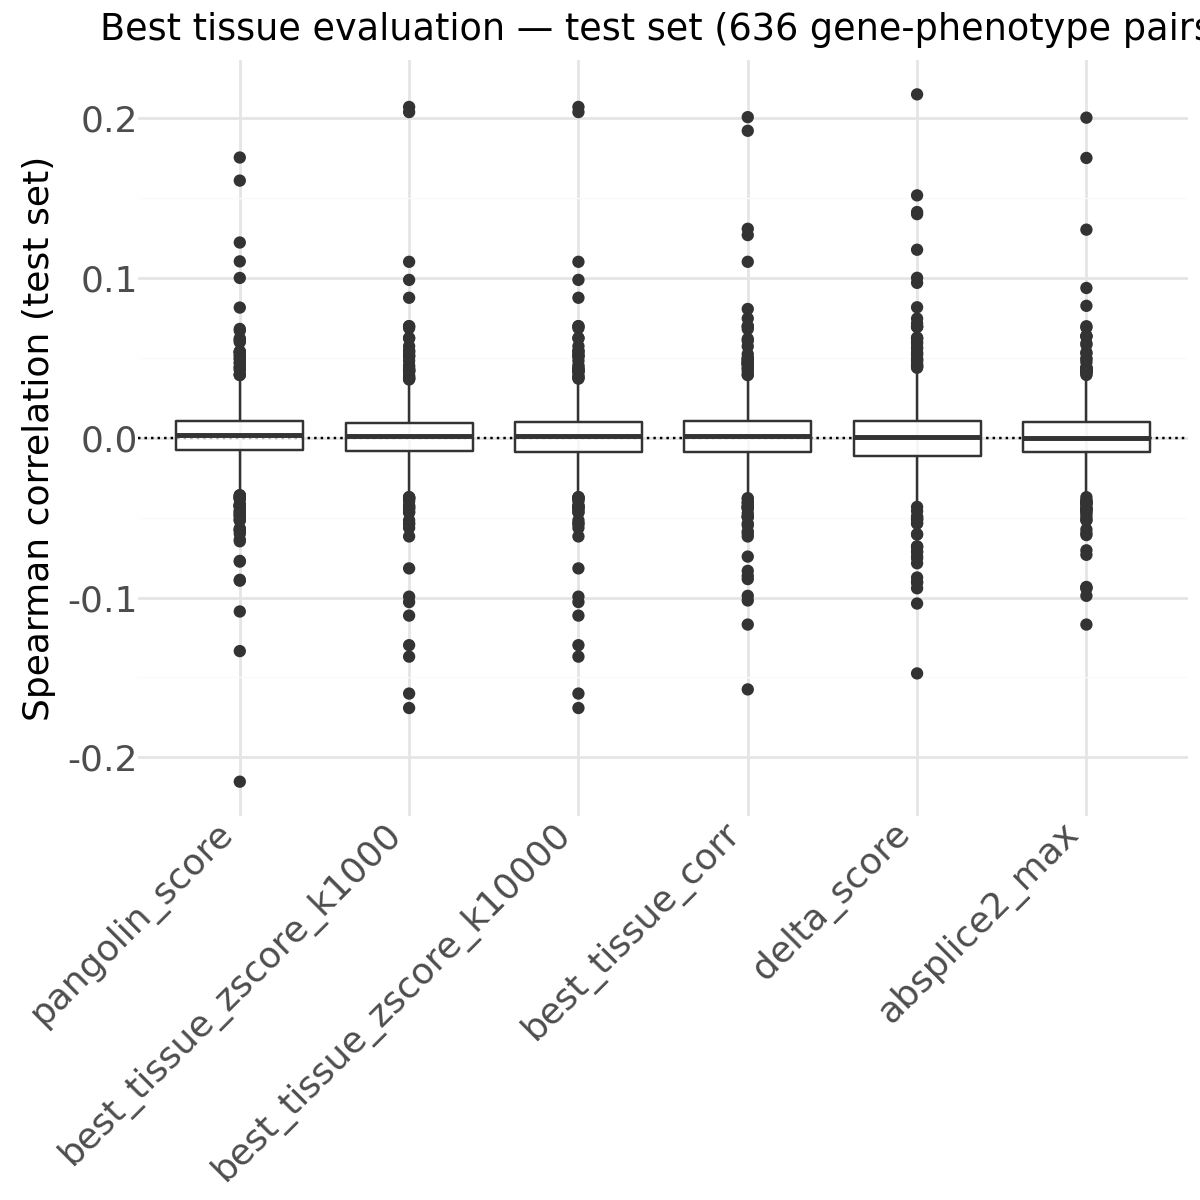

In [ ]:
# Boxplot of corr_beta on the test set, one box per annotation
corr_test_pl = (
    test_corr_results
    .drop_nans()
    .filter(pl.col('n_variants') > 50)
    .with_columns(median_corr_beta=pl.col('corr_beta').median().over("annotation"))
)
ordered_test_labels = (
    corr_test_pl
    .sort("median_corr_beta", descending=True)
    .select("annotation")
    .unique(maintain_order=True)
    .to_series()
)
corr_test_pl = corr_test_pl.with_columns(pl.col("annotation").cast(pl.Enum(ordered_test_labels)))

(
    ggplot(corr_test_pl, aes(x="annotation", y="corr_beta"))
    + geom_hline(aes(yintercept=0), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7)
    + theme_minimal()
    + labs(
        x="",
        y="Spearman correlation (test set)",
        title=f"Best tissue evaluation — test set ({len(corr_test_pl['region'].unique())} gene-phenotype pairs)",
    )
    + theme(
        figure_size=(6, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        axis_text_x=element_text(rotation=45, hjust=1),
        plot_background=element_rect(fill="white", color="white"),
    )
)

---
## Avg z-score of top N variants — sliding window + bootstrap (test set)

In [ ]:
# Parameters (match those in pheno_avg_zscore_gene_bootstrap.ipynb)
window_size_test = 1_000
step_size_test = 10
n_boot_test = 1_000
max_num_variants = 100_000
target_k_test = np.array([1_000, 10_000], dtype=np.int64)
ci_factor_test = 1  # ±1 SE bands

# Melt test_comparison into long format
test_melted_comp = (
    test_comparison.lazy()
    .unpivot(index=['id', 'region'], on=comp_cols, variable_name='annotation', value_name='annotation_score')
    .drop_nulls('annotation_score')
    .collect()
)

# Gene index map for bootstrap resampling
all_regions_test = sorted(gene_trait_df['region'].unique().to_list())
n_regions_test = len(all_regions_test)
region_idx_map_test = pl.DataFrame({
    'region': all_regions_test,
    '_region_idx': np.arange(n_regions_test, dtype=np.int32)
})

# Direction-correct z-scores: multiply by loftee_corr_dir so that
# "deleterious" variants always have positive z-scores (same as pheno_avg_zscore_gene_bootstrap)
# Then rank by annotation_score descending (higher = more disruptive)
ranked_test_zscores = (
    test_melted_comp.lazy()
    .join(
        test_variant_zscores.lazy().select(['id', 'region', 'mean_pheno_value', 'loftee_corr_dir']),
        on=['id', 'region'], how='inner'
    )
    .with_columns(
        mean_pheno_value=pl.col('mean_pheno_value') * pl.col('loftee_corr_dir').cast(pl.Float32),
    )
    .with_columns(
        annotation_score_dircor_rank_desc=(
            pl.col('annotation_score').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
        )
    )
    .sort(['annotation', 'annotation_score_dircor_rank_desc'])
    .with_columns(row_pos=pl.col('annotation').cum_count().over('annotation'))
    .pipe(lambda df: df.filter(pl.col('row_pos') <= max_num_variants) if max_num_variants is not None else df)
    .collect(engine='streaming')
    .join(region_idx_map_test, on='region', how='left')
)

annotations_list_test = sorted(ranked_test_zscores['annotation'].unique().to_list())
print(f"Annotations: {annotations_list_test}")
print(f"Ranked test z-score table: {ranked_test_zscores.shape}")

Annotations: ['absplice2_max', 'best_tissue_corr', 'best_tissue_zscore_k1000', 'best_tissue_zscore_k10000', 'delta_score', 'pangolin_score']
Ranked test z-score table: (600000, 9)


In [ ]:
# --- Helper functions (same as pheno_avg_zscore_gene_bootstrap.ipynb) ---

def sliding_window_means_unweighted(zscores, bin_ends, window_size):
    """Standard prefix-sum sliding window mean (for point estimates)."""
    csum = np.empty(len(zscores) + 1, dtype=np.float64)
    csum[0] = 0.0
    np.cumsum(zscores, out=csum[1:])
    return (csum[bin_ends] - csum[bin_ends - window_size]) / window_size


def expanded_csum_at(positions, cw, cwz, z, N):
    k = np.searchsorted(cw, positions, side='left')
    k_safe = np.clip(k, 1, N)
    result = cwz[k_safe - 1] + z[k_safe - 1] * (positions - cw[k_safe - 1])
    result = np.where(positions <= 0, 0.0, result)
    return result


def sliding_window_reranked(z, cw, cwz, N, total_expanded, bin_ends, window_size):
    valid_mask = bin_ends <= total_expanded
    valid_bins = bin_ends[valid_mask]
    means = np.full(len(bin_ends), np.nan, dtype=np.float64)
    if len(valid_bins) == 0:
        return means
    right = expanded_csum_at(valid_bins, cw, cwz, z, N)
    left = expanded_csum_at(valid_bins - window_size, cw, cwz, z, N)
    means[valid_mask] = (right - left) / window_size
    return means


# --- Prepare per-annotation arrays ---
anno_arrays_test = {}
for annotation in tqdm(annotations_list_test, desc='Preparing arrays'):
    adf = ranked_test_zscores.filter(pl.col('annotation') == annotation)
    z = adf['mean_pheno_value'].to_numpy().astype(np.float64)
    r_idx = adf['_region_idx'].to_numpy()
    N = len(z)
    bin_ends = np.arange(window_size_test, N + 1, step_size_test, dtype=np.int64)
    anno_arrays_test[annotation] = {'zscores': z, 'region_idx': r_idx, 'bin_ends': bin_ends, 'N': N}

# Filter target_k to available variant counts
min_variants_test = min(d['N'] for d in anno_arrays_test.values())
target_k_test = target_k_test[target_k_test <= min_variants_test]
print(f"Heatmap thresholds: {target_k_test} (min variants: {min_variants_test})")

# --- Point estimates ---
point_means_test = {
    ann: sliding_window_means_unweighted(anno_arrays_test[ann]['zscores'], anno_arrays_test[ann]['bin_ends'], window_size_test)
    for ann in annotations_list_test
}

# --- Re-ranking bootstrap CIs across genes ---
rng_test = np.random.default_rng(42)
boot_means_test = {ann: np.full((n_boot_test, len(anno_arrays_test[ann]['bin_ends'])), np.nan) for ann in annotations_list_test}
boot_discrete_test = {ann: np.full((n_boot_test, len(target_k_test)), np.nan) for ann in annotations_list_test}

max_N_test = max(d['N'] for d in anno_arrays_test.values())
cw_buf = np.empty(max_N_test + 1, dtype=np.float64)
cwz_buf = np.empty(max_N_test + 1, dtype=np.float64)

for b in tqdm(range(n_boot_test), desc='Bootstrap (test set)'):
    idx = rng_test.choice(n_regions_test, size=n_regions_test, replace=True)
    region_weights = np.bincount(idx, minlength=n_regions_test).astype(np.float64)

    for annotation in annotations_list_test:
        d = anno_arrays_test[annotation]
        N = d['N']
        z = d['zscores']
        vw = region_weights[d['region_idx']]

        cw = cw_buf[:N + 1]
        cw[0] = 0.0
        np.cumsum(vw, out=cw[1:])

        cwz = cwz_buf[:N + 1]
        cwz[0] = 0.0
        np.cumsum(z * vw, out=cwz[1:])

        total_expanded = int(cw[N])

        boot_means_test[annotation][b] = sliding_window_reranked(
            z, cw, cwz, N, total_expanded, d['bin_ends'], window_size_test
        )

        csums = expanded_csum_at(target_k_test, cw, cwz, z, N)
        boot_discrete_test[annotation][b] = csums / target_k_test

# --- Build output DataFrame ---
all_results_test = []
for annotation in tqdm(annotations_list_test):
    d = anno_arrays_test[annotation]
    bm = boot_means_test[annotation]
    boot_mean = np.nanmean(bm, axis=0)
    boot_se = np.nanstd(bm, axis=0).astype(np.float32)
    all_results_test.append(pl.DataFrame({
        'annotation': annotation,
        'bin_end': d['bin_ends'].astype(np.float64),
        'mean_zscore': boot_mean,
        'se_zscore': boot_se,
        'ci_lower': (boot_mean - ci_factor_test * boot_se).astype(np.float32),
        'ci_upper': (boot_mean + ci_factor_test * boot_se).astype(np.float32),
    }))

zscore_binned_test = pl.concat(all_results_test).sort(['annotation', 'bin_end'])
print(f"Sliding window results: {zscore_binned_test.shape[0]} points across {zscore_binned_test['annotation'].n_unique()} annotations")
zscore_binned_test

Preparing arrays: 100%|██████████| 6/6 [00:00<00:00, 226.29it/s]

Heatmap thresholds: [ 1000 10000] (min variants: 100000)


100%|██████████| 6/6 [00:00<00:00,  6.41it/s]

Sliding window results: 59406 points across 6 annotations


annotation,bin_end,mean_zscore,se_zscore,ci_lower,ci_upper
str,f64,f64,f32,f32,f32
"""absplice2_max""",1000.0,0.142298,0.038704,0.103595,0.181002
"""absplice2_max""",1010.0,0.148287,0.039375,0.108912,0.187663
"""absplice2_max""",1020.0,0.15667,0.040148,0.116522,0.196818
"""absplice2_max""",1030.0,0.164,0.040613,0.123387,0.204614
"""absplice2_max""",1040.0,0.168237,0.041369,0.126868,0.209607
…,…,…,…,…,…
"""pangolin_score""",99960.0,0.157076,0.395806,-0.23873,0.552882
"""pangolin_score""",99970.0,0.157046,0.39554,-0.238494,0.552586
"""pangolin_score""",99980.0,0.157103,0.395352,-0.238248,0.552455


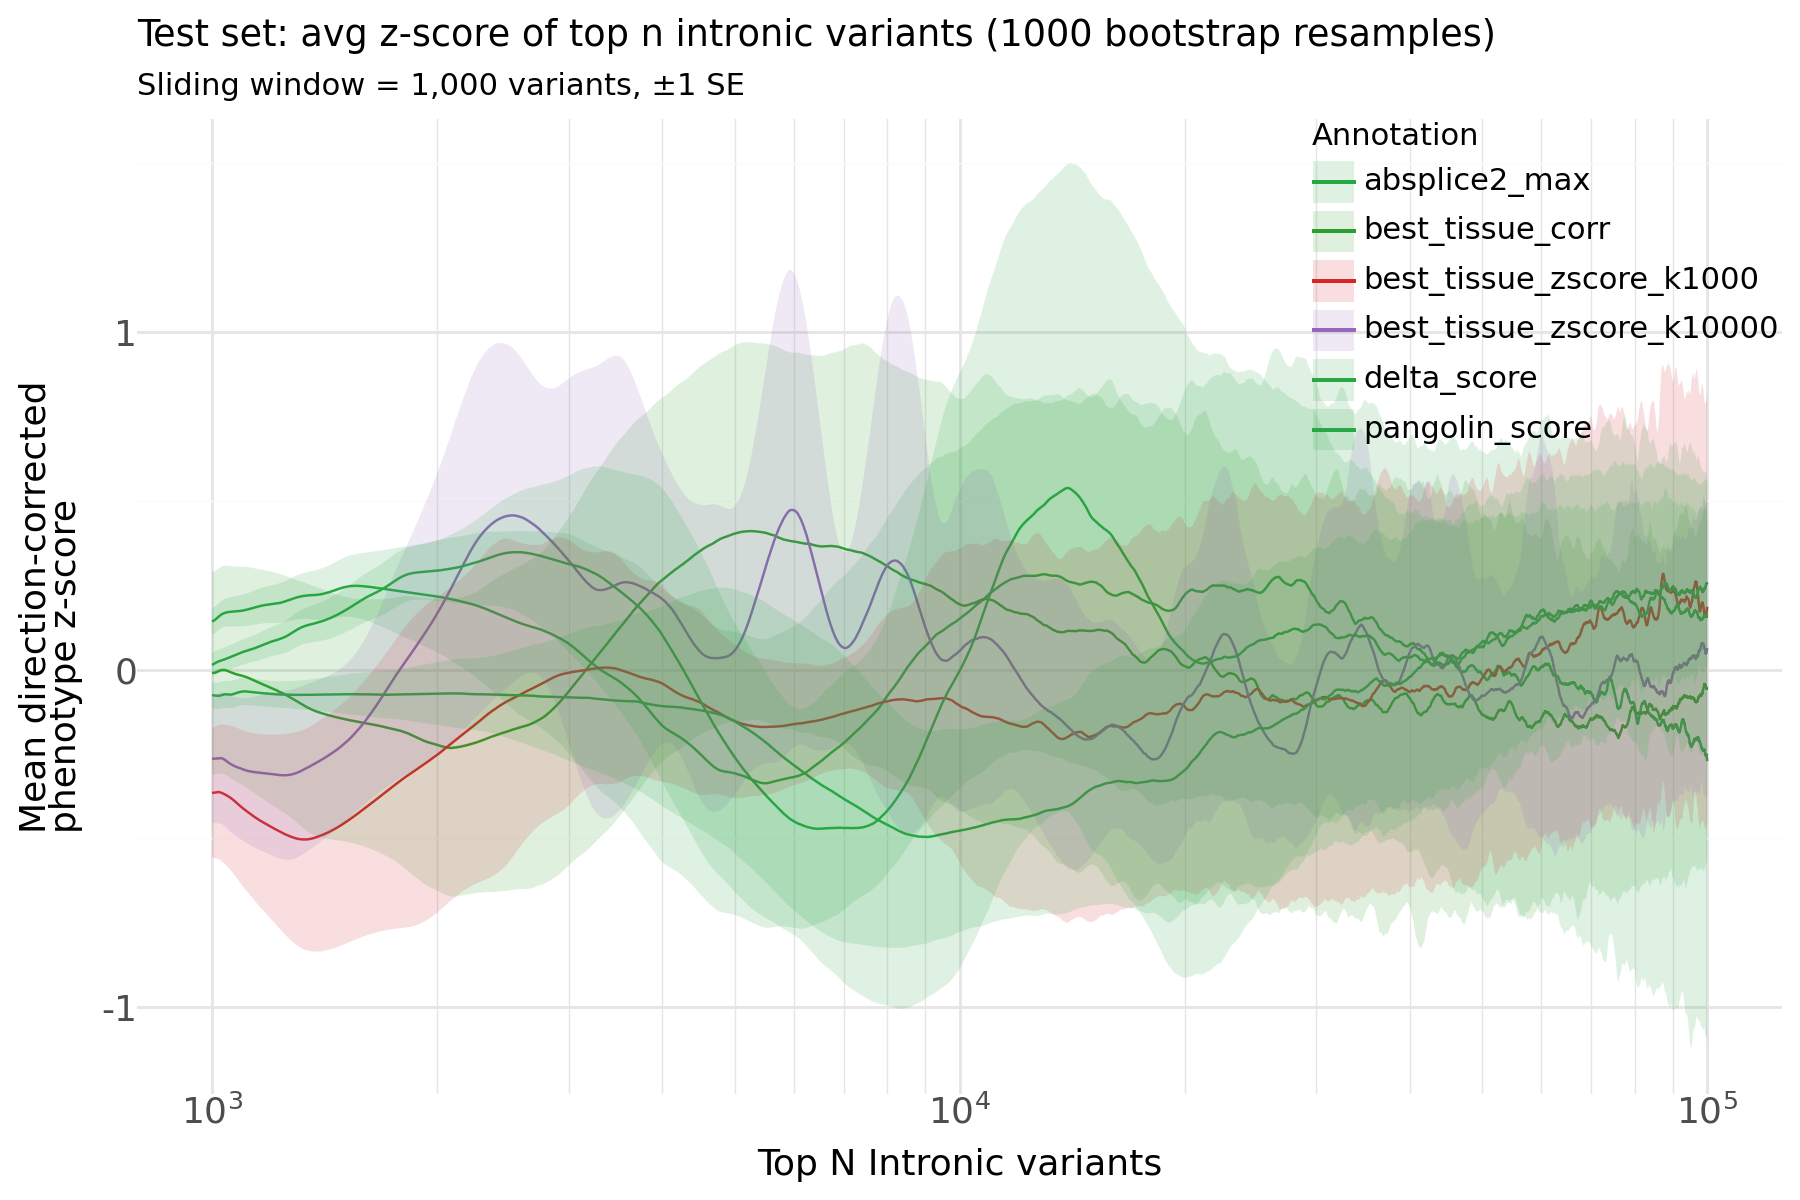

In [ ]:
# Line plot: sliding window avg z-score on test set
# color_map is defined in the config cell (best-tissue + baseline colors)

plt_df_test = (
    zscore_binned_test
    .drop_nans()
    .filter(pl.col('bin_end') <= 100_000)
    .with_columns(log_bin_end=pl.col('bin_end').log10())
    .with_columns(color=pl.col('annotation').replace(color_map))
)

max_rank_t = zscore_binned_test['bin_end'].max()
min_rank_t = zscore_binned_test['bin_end'].min()
start_exp_t = int(np.floor(np.log10(min_rank_t)))
end_exp_t = int(np.ceil(np.log10(max_rank_t)))
breaks_t = np.arange(start_exp_t, end_exp_t + 1)
labels_t = [f"$10^{{{int(b)}}}$" for b in breaks_t]
minor_breaks_t = [b for k in range(start_exp_t, end_exp_t) for b in [k + np.log10(m) for m in range(2, 10)] if min_rank_t <= 10**b <= max_rank_t]

color_dict_test = dict(zip(plt_df_test['annotation'], plt_df_test['color']))

(
    ggplot(plt_df_test, aes(x='log_bin_end', y='mean_zscore'))
    + geom_line(aes(color='annotation'))
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='annotation'), alpha=0.15)
    + scale_color_manual(values=color_dict_test)
    + scale_fill_manual(values=color_dict_test)
    + scale_x_continuous(breaks=breaks_t, labels=labels_t, minor_breaks=minor_breaks_t)
    + labs(
        title=f"Test set: avg z-score of {x_label.lower()} ({n_boot_test} bootstrap resamples)",
        subtitle=f"Sliding window = {window_size_test:,} variants, ±{ci_factor_test} SE",
        y="Mean direction-corrected\nphenotype z-score",
        x=x_label,
        color="Annotation",
        fill="Annotation",
    )
    + theme_minimal()
    + theme(
        figure_size=(9, 6),
        legend_position=(1, 1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        panel_grid_minor_x=element_line(color="#e5e5e5", size=0.5),
        legend_text=element_text(size=11),
        legend_title=element_text(size=11),
        plot_background=element_rect(fill="white", color="white"),
    )
)

# FIXME: Plots looks weird, why are confidence intervals so big?

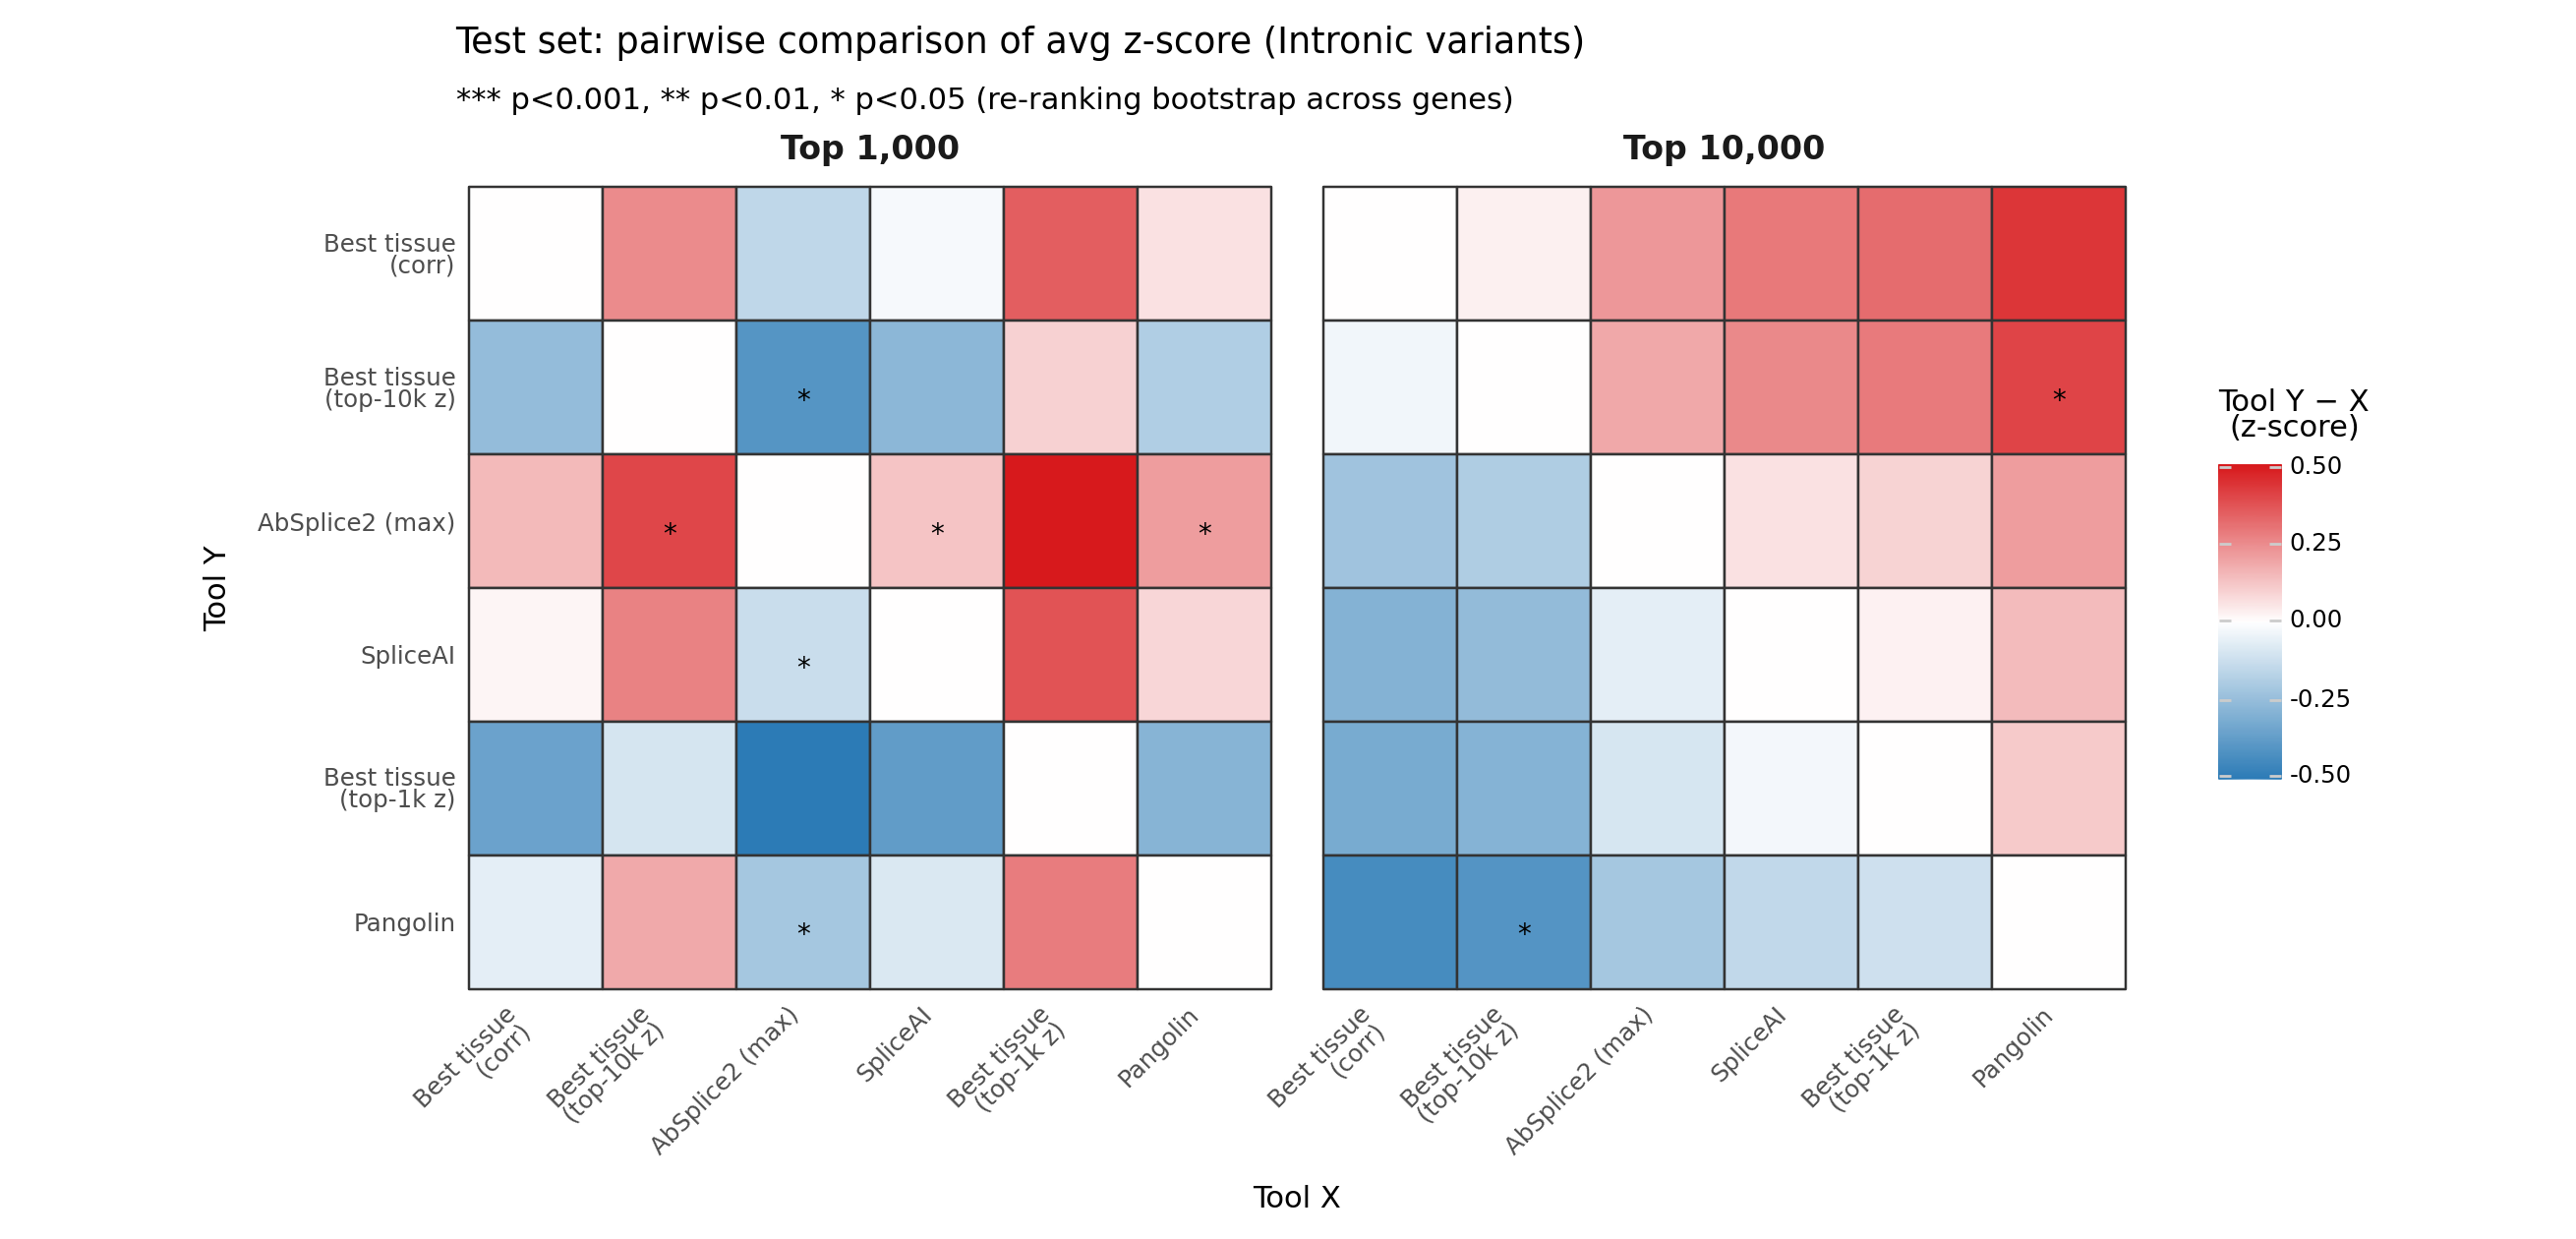

In [ ]:
import pandas as pd
import itertools

# Heatmap of pairwise bootstrap significance on test set
# label_map is defined in the config cell (best-tissue + baseline labels)

# Rank tools by mean z-score
# rank_idx_t = 0 # order by top 1_000
rank_idx_t = 1 # order by top 10_000
tool_means_t = {ann: np.nanmean(boot_discrete_test[ann][:, rank_idx_t]) for ann in annotations_list_test}
ordered_tools_t = sorted(tool_means_t.keys(), key=lambda x: tool_means_t[x], reverse=True)
ordered_labels_t = [label_map.get(t, t) for t in ordered_tools_t]

heatmap_data_t = []
for i, k_val in enumerate(target_k_test):
    for ann_x, ann_y in itertools.product(ordered_tools_t, repeat=2):
        label_x = label_map.get(ann_x, ann_x)
        label_y = label_map.get(ann_y, ann_y)
        if ann_x == ann_y:
            heatmap_data_t.append({'Window': f"Top {k_val:,}", 'Window_Int': k_val,
                                   'Tool_X': label_x, 'Tool_Y': label_y, 'mean_diff': 0.0, 'sig': ''})
            continue
        boot_x = boot_discrete_test[ann_x][:, i]
        boot_y = boot_discrete_test[ann_y][:, i]
        diff = boot_y - boot_x
        mean_diff = np.nanmean(diff)
        p_val = 2 * min(np.nanmean(diff <= 0), np.nanmean(diff >= 0))
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
        heatmap_data_t.append({'Window': f"Top {k_val:,}", 'Window_Int': k_val,
                                'Tool_X': label_x, 'Tool_Y': label_y, 'mean_diff': mean_diff, 'sig': sig})

df_heat_t = pd.DataFrame(heatmap_data_t).sort_values('Window_Int')
df_heat_t['Window'] = pd.Categorical(df_heat_t['Window'], categories=df_heat_t['Window'].unique(), ordered=True)
df_heat_t['Tool_X'] = pd.Categorical(df_heat_t['Tool_X'], categories=ordered_labels_t, ordered=True)
df_heat_t['Tool_Y'] = pd.Categorical(df_heat_t['Tool_Y'], categories=ordered_labels_t[::-1], ordered=True)

n_facets_t = len(target_k_test)
n_tools_t = len(ordered_tools_t)

(
    ggplot(df_heat_t, aes(x='Tool_X', y='Tool_Y', fill='mean_diff'))
    + geom_tile(color="#333333", size=0.5)
    + geom_text(aes(label='sig'), color="black", size=10, va='center', nudge_y=-0.1)
    + facet_wrap('~Window', ncol=n_facets_t)
    + scale_fill_gradient2(low="#2C7BB6", mid="#FFFFFF", high="#D7191C", midpoint=0)
    + labs(
        title=f"Test set: pairwise comparison of avg z-score ({vc['x_label']} variants)",
        subtitle="*** p<0.001, ** p<0.01, * p<0.05 (re-ranking bootstrap across genes)",
        x="Tool X", y="Tool Y", fill="Tool Y − X\n(z-score)"
    )
    + theme_minimal()
    + theme(
        figure_size=(n_facets_t * (n_tools_t * 0.8 + 1.0) + 1.5, n_tools_t * 0.8 + 1.5),
        aspect_ratio=1,
        axis_text_x=element_text(rotation=45, hjust=1),
        strip_text=element_text(size=12, face='bold'),
        panel_grid=element_blank(),
        plot_background=element_rect(fill="white", color="white"),
    )
)

---
# Best tissue CV

In [19]:
n_cv_folds = 2  # Number of cross-validation folds

rng_cv = np.random.default_rng(42)
id_region_all_cv = anno.select(['id', 'region']).unique()
n_pairs_cv = len(id_region_all_cv)

cv_fold_assignments = (
    id_region_all_cv
    .with_columns(fold=pl.Series(rng_cv.integers(0, n_cv_folds, n_pairs_cv, dtype=np.int32)))
)
print(f"Total (id, region) pairs: {n_pairs_cv:,}, folds: {n_cv_folds}")
cv_fold_assignments.group_by('fold').agg(pl.len().alias('n_pairs')).sort('fold')


Total (id, region) pairs: 12,088,072, folds: 2


fold,n_pairs
i32,u64
0,6044277
1,6043795


In [ ]:
import gc

# CV loop: for each fold, train on remaining folds, predict on held-out fold.
# Produces test_comparison_cv covering ALL (id, region) pairs.
cv_test_comparisons = []

for fold in range(n_cv_folds):
    print(f"\n--- Fold {fold+1}/{n_cv_folds} ---")
    cv_train_df = cv_fold_assignments.filter(pl.col('fold') != fold).select(['id', 'region'])
    cv_test_df  = cv_fold_assignments.filter(pl.col('fold') == fold).select(['id', 'region'])

    # ── Best tissue by correlation on train ──
    # Keep melted_anno filtered lazily — avoid materializing the full semi-join
    cv_train_melted_gtex_lazy = (
        melted_anno.lazy()
        .join(cv_train_df.lazy(), on=['id', 'region'], how='semi')
        .filter(pl.col('annotation').is_in(tissue_cols))
    )
    cv_train_corr_df = (
        pheno_appv
        .join(cv_train_df.lazy(), on='id', how='inner')
        .join(gene_trait_df[["region", "phenotype"]].lazy(), on=["region", "phenotype"], how="inner")
        .join(cv_train_melted_gtex_lazy, on=["id", "region"], how="inner")
        .with_columns(
            pl.col(c).rank("max").over(["region", "phenotype", "annotation"]).alias(f"{c}_rank")
            for c in ['mean_pheno_value', 'annotation_score']
        )
        .group_by(["region", "phenotype", "annotation"])
        .agg(
            n_variants=pl.col("id").count(),
            correlation=pl.when(
                (pl.col("annotation_score_rank").n_unique() > 1) &
                (pl.col("mean_pheno_value_rank").n_unique() > 1)
            ).then(pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True))
            .otherwise(None)
        )
        .join(gene_trait_df.lazy(), on=['region', 'phenotype'])
        .with_columns(corr_beta=pl.col('correlation') * pl.col('loftee_corr_dir'))
        .drop_nans().drop_nulls()
        .collect(engine='streaming')
    )
    cv_best_tissue_corr = (
        cv_train_corr_df
        .filter(pl.col('n_variants') >= 50)
        .sort(['corr_beta', 'annotation'], descending=[True, False])
        .unique(subset=['region'], keep='first', maintain_order=True)
        .select(['region', pl.col('annotation').alias('best_tissue_corr'), 'corr_beta'])
    )
    del cv_train_corr_df

    # ── Best tissue by avg z-score on train ──
    # Direction-correct mean_pheno_value so positive = consistent with gene impairment
    cv_train_variant_zscores = (
        pheno_appv
        .join(cv_train_df.lazy(), on='id', how='inner')
        .join(gene_trait_df[["region", "phenotype", "loftee_corr_dir"]].lazy(), on=["region", "phenotype"], how="inner")
        .with_columns(
            mean_pheno_value=pl.col('mean_pheno_value') * pl.col('loftee_corr_dir').cast(pl.Float32),
        )
        .select(['id', 'region', 'mean_pheno_value'])
        .collect(engine='streaming')
    )
    cv_train_tissue_with_z = (
        cv_train_melted_gtex_lazy
        .join(cv_train_variant_zscores.lazy(), on=['id', 'region'], how='inner')
        .with_columns(
            tissue_rank=pl.col('annotation_score').rank('min', descending=True).over(['region', 'annotation'])
        )
        .collect(engine='streaming')
    )
    del cv_train_variant_zscores

    cv_best_tissue_zscore = {}
    for top_k in top_k_list:
        cv_best_tissue_zscore[top_k] = (
            cv_train_tissue_with_z.lazy()
            .filter(pl.col('tissue_rank') <= top_k)
            .group_by(['region', 'annotation'])
            .agg(mean_zscore_topk=pl.col('mean_pheno_value').mean(), n_vars=pl.len())
            .sort(['mean_zscore_topk', 'annotation'], descending=[True, False])
            .unique(subset=['region'], keep='first', maintain_order=True)
            .select(['region', pl.col('annotation').alias(f'best_tissue_zscore_k{top_k}'), 'mean_zscore_topk'])
            .collect()
        )
    del cv_train_tissue_with_z

    # ── Apply best tissue to test fold ──
    cv_test_melted_gtex_lazy = (
        melted_anno.lazy()
        .join(cv_test_df.lazy(), on=['id', 'region'], how='semi')
        .filter(pl.col('annotation').is_in(tissue_cols))
    )
    fold_scores_corr = (
        cv_test_melted_gtex_lazy
        .join(cv_best_tissue_corr.lazy().rename({'best_tissue_corr': 'annotation'}), on=['region', 'annotation'], how='inner')
        .select(['id', 'region', pl.col('annotation_score').alias('best_tissue_corr')])
        .collect()
    )
    del cv_best_tissue_corr

    fold_scores_zscore = {}
    for top_k in top_k_list:
        col_name = f'best_tissue_zscore_k{top_k}'
        fold_scores_zscore[top_k] = (
            cv_test_melted_gtex_lazy
            .join(cv_best_tissue_zscore[top_k].lazy().rename({f'best_tissue_zscore_k{top_k}': 'annotation'}), on=['region', 'annotation'], how='inner')
            .select(['id', 'region', pl.col('annotation_score').alias(col_name)])
            .collect()
        )
    del cv_best_tissue_zscore

    fold_baseline = (
        melted_anno.lazy()
        .join(cv_test_df.lazy(), on=['id', 'region'], how='semi')
        .filter(pl.col('annotation').is_in(baseline_annos))
        .collect()
        .pivot(index=['id', 'region'], on='annotation', values='annotation_score', aggregate_function='first')
    )

    fold_comparison = fold_scores_corr.lazy()
    for top_k in top_k_list:
        fold_comparison = fold_comparison.join(fold_scores_zscore[top_k].lazy(), on=['id', 'region'], how='full', coalesce=True)
    fold_comparison = fold_comparison.join(fold_baseline.lazy(), on=['id', 'region'], how='full', coalesce=True).collect()

    del fold_scores_corr, fold_scores_zscore, fold_baseline
    cv_test_comparisons.append(fold_comparison)
    print(f"  Fold {fold+1} test rows: {fold_comparison.shape[0]:,}")
    del fold_comparison
    gc.collect()

test_comparison_cv = pl.concat(cv_test_comparisons)
del cv_test_comparisons
gc.collect()
print(f"\nCV comparison total: {test_comparison_cv.shape}")
test_comparison_cv.head()

---
## CV evaluation — Spearman correlation

In [21]:
id_region = anno.select(['id', 'region']).unique().lazy()
comp_cols_cv = [c for c in comp_cols if c in test_comparison_cv.columns]

# All (id, region) pairs are covered by CV, so no fold filter needed
cv_variant_zscores = (
    pheno_appv
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df[["region", "phenotype", "loftee_corr_dir"]].lazy(), on=['region', 'phenotype'], how='inner')
    .select(['id', 'region', 'phenotype', 'mean_pheno_value', 'loftee_corr_dir'])
    .collect(engine='streaming')
)

all_cv_corrs = []
for col in comp_cols_cv:
    corr_df = (
        cv_variant_zscores.lazy()
        .join(test_comparison_cv.lazy().select(['id', 'region', col]).drop_nulls(), on=['id', 'region'], how='inner')
        .with_columns(
            anno_rank=pl.col(col).rank("average").over(["region", "phenotype"]),
            pheno_rank=pl.col('mean_pheno_value').rank("average").over(["region", "phenotype"]),
        )
        .group_by(["region", "phenotype"])
        .agg(
            n_variants=pl.col('id').count(),
            correlation=pl.corr("anno_rank", "pheno_rank", propagate_nans=True)
        )
        .join(gene_trait_df.lazy(), on=['region', 'phenotype'])
        .with_columns(
            corr_beta=pl.col('correlation') * pl.col('loftee_corr_dir'),
            annotation=pl.lit(col)
        )
        .collect()
    )
    all_cv_corrs.append(corr_df)

test_corr_results_cv = pl.concat(all_cv_corrs)
test_corr_summary_cv = (
    test_corr_results_cv
    .drop_nans()
    .group_by('annotation')
    .agg(
        n_genes=pl.len(),
        mean_corr_beta=pl.col('corr_beta').mean(),
        median_corr_beta=pl.col('corr_beta').median(),
        se_corr_beta=pl.col('corr_beta').std() / pl.col('corr_beta').len().sqrt(),
    )
    .sort('mean_corr_beta', descending=True)
)
test_corr_summary_cv

annotation,n_genes,mean_corr_beta,median_corr_beta,se_corr_beta
str,u64,f64,f64,f64
"""delta_score""",635,0.002353,0.001527,0.000824
"""absplice2_max""",640,0.001868,0.000786,0.000885
"""best_tissue_zscore_k1000""",640,0.001674,0.000748,0.000833
"""best_tissue_zscore_k10000""",640,0.001559,0.00021,0.000832
"""best_tissue_corr""",637,0.001273,0.000408,0.000723
"""pangolin_score""",640,0.001252,0.000353,0.000844


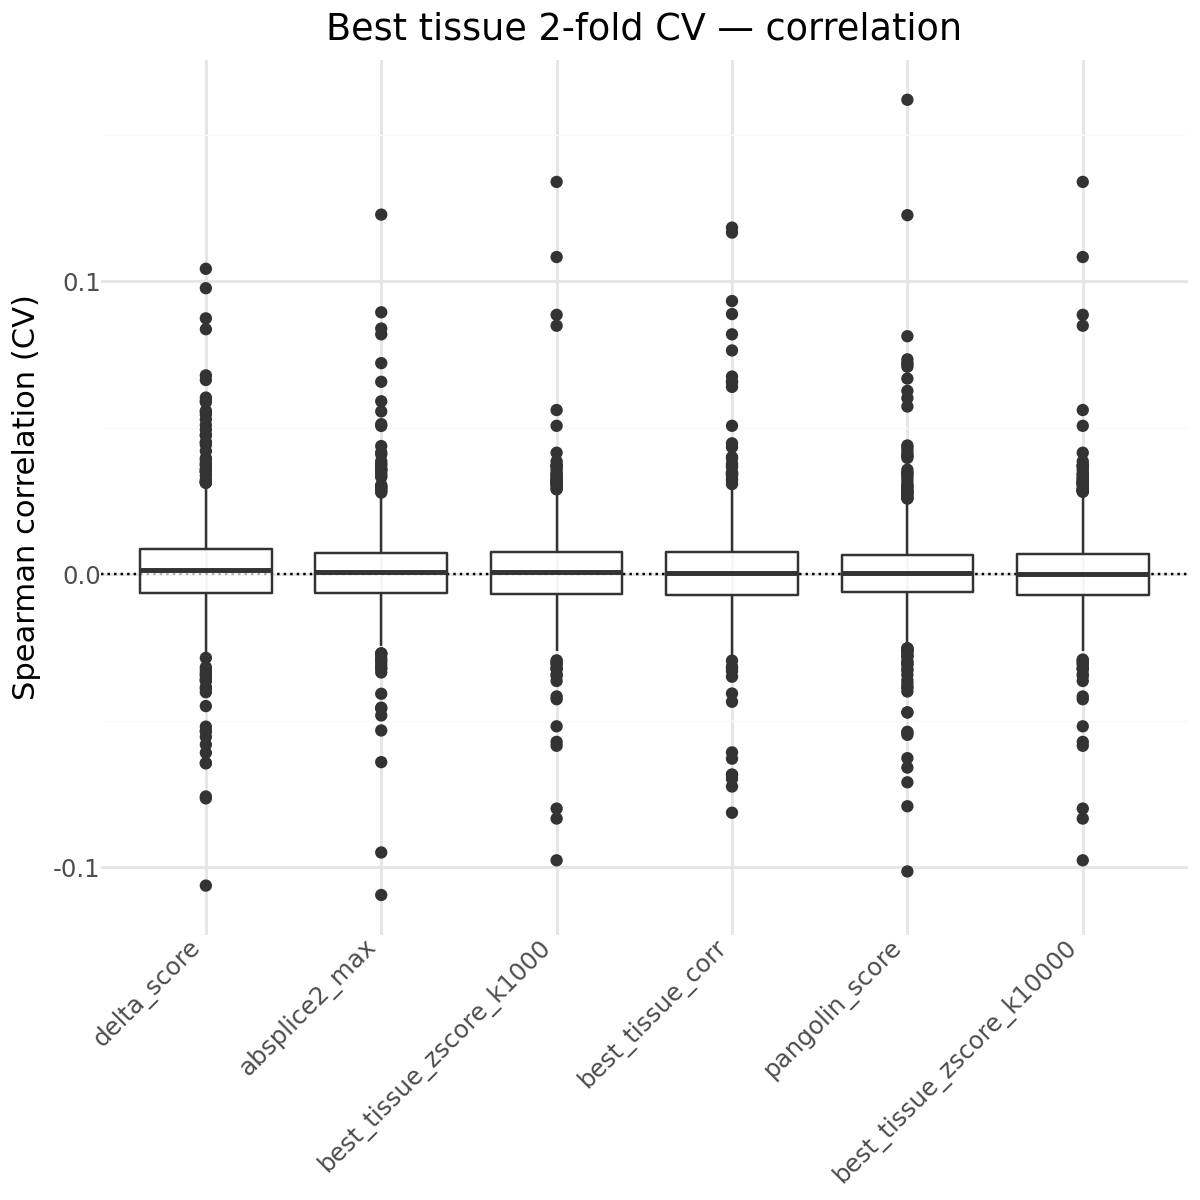

: 

In [ ]:
corr_cv_pl = (
    test_corr_results_cv
    .drop_nans()
    .filter(pl.col('n_variants') > 50)
    .with_columns(median_corr_beta=pl.col('corr_beta').median().over("annotation"))
)
ordered_cv_labels = (
    corr_cv_pl.sort("median_corr_beta", descending=True)
    .select("annotation").unique(maintain_order=True).to_series()
)
corr_cv_pl = corr_cv_pl.with_columns(pl.col("annotation").cast(pl.Enum(ordered_cv_labels)))

(
    ggplot(corr_cv_pl, aes(x="annotation", y="corr_beta"))
    + geom_hline(aes(yintercept=0), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7)
    + theme_minimal()
    + labs(x="", y="Spearman correlation (CV)", title=f"Best tissue {n_cv_folds}-fold CV — correlation")
    + theme(
        figure_size=(6, 6), 
        axis_text_x=element_text(rotation=45, hjust=1),
        plot_background=element_rect(fill="white", color="white")
    )
)


---
## CV evaluation — sliding window avg z-score + bootstrap

In [ ]:
window_size_cv = 1_000
step_size_cv = 10
n_boot_cv = 1_000
max_num_variants = 100_000
target_k_cv = np.array([1_000, 10_000], dtype=np.int64)
ci_factor_cv = 1

cv_melted_comp = (
    test_comparison_cv.lazy()
    .unpivot(index=['id', 'region'], on=comp_cols_cv, variable_name='annotation', value_name='annotation_score')
    .drop_nulls('annotation_score')
    .collect()
)

all_regions_cv = sorted(gene_trait_df['region'].unique().to_list())
n_regions_cv = len(all_regions_cv)
region_idx_map_cv = pl.DataFrame({
    'region': all_regions_cv,
    '_region_idx': np.arange(n_regions_cv, dtype=np.int32)
})

# Direction-correct z-scores and rank by annotation_score descending
ranked_cv_zscores = (
    cv_melted_comp.lazy()
    .join(
        cv_variant_zscores.lazy().select(['id', 'region', 'mean_pheno_value', 'loftee_corr_dir']),
        on=['id', 'region'], how='inner'
    )
    .with_columns(
        mean_pheno_value=pl.col('mean_pheno_value') * pl.col('loftee_corr_dir').cast(pl.Float32),
    )
    .with_columns(
        annotation_score_dircor_rank_desc=(
            pl.col('annotation_score').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
        )
    )
    .sort(['annotation', 'annotation_score_dircor_rank_desc'])
    .with_columns(row_pos=pl.col('annotation').cum_count().over('annotation'))
    .pipe(lambda df: df.filter(pl.col('row_pos') <= max_num_variants) if max_num_variants is not None else df)
    .collect(engine='streaming')
    .join(region_idx_map_cv, on='region', how='left')
)

annotations_list_cv = sorted(ranked_cv_zscores['annotation'].unique().to_list())
print(f"Annotations: {annotations_list_cv}")
print(f"Ranked CV z-scores: {ranked_cv_zscores.shape}")

In [ ]:
# Prepare per-annotation arrays
anno_arrays_cv = {}
for annotation in tqdm(annotations_list_cv, desc='Preparing arrays'):
    adf = ranked_cv_zscores.filter(pl.col('annotation') == annotation)
    z = adf['mean_pheno_value'].to_numpy().astype(np.float64)
    r_idx = adf['_region_idx'].to_numpy()
    N = len(z)
    bin_ends = np.arange(window_size_cv, N + 1, step_size_cv, dtype=np.int64)
    anno_arrays_cv[annotation] = {'zscores': z, 'region_idx': r_idx, 'bin_ends': bin_ends, 'N': N}

min_variants_cv = min(d['N'] for d in anno_arrays_cv.values())
target_k_cv = target_k_cv[target_k_cv <= min_variants_cv]
print(f"Heatmap thresholds: {target_k_cv} (min variants: {min_variants_cv})")

# Point estimates
point_means_cv = {
    ann: sliding_window_means_unweighted(anno_arrays_cv[ann]['zscores'], anno_arrays_cv[ann]['bin_ends'], window_size_cv)
    for ann in annotations_list_cv
}

# Bootstrap
rng_cv_boot = np.random.default_rng(42)
boot_means_cv = {ann: np.full((n_boot_cv, len(anno_arrays_cv[ann]['bin_ends'])), np.nan) for ann in annotations_list_cv}
boot_discrete_cv = {ann: np.full((n_boot_cv, len(target_k_cv)), np.nan) for ann in annotations_list_cv}

max_N_cv = max(d['N'] for d in anno_arrays_cv.values())
cw_buf_cv  = np.empty(max_N_cv + 1, dtype=np.float64)
cwz_buf_cv = np.empty(max_N_cv + 1, dtype=np.float64)

for b in tqdm(range(n_boot_cv), desc='Bootstrap (CV)'):
    idx = rng_cv_boot.choice(n_regions_cv, size=n_regions_cv, replace=True)
    region_weights = np.bincount(idx, minlength=n_regions_cv).astype(np.float64)

    for annotation in annotations_list_cv:
        d = anno_arrays_cv[annotation]
        N = d['N']
        z = d['zscores']
        vw = region_weights[d['region_idx']]

        cw = cw_buf_cv[:N + 1]
        cw[0] = 0.0
        np.cumsum(vw, out=cw[1:])

        cwz = cwz_buf_cv[:N + 1]
        cwz[0] = 0.0
        np.cumsum(z * vw, out=cwz[1:])

        total_expanded = int(cw[N])

        boot_means_cv[annotation][b] = sliding_window_reranked(
            z, cw, cwz, N, total_expanded, d['bin_ends'], window_size_cv
        )
        csums = expanded_csum_at(target_k_cv, cw, cwz, z, N)
        boot_discrete_cv[annotation][b] = csums / target_k_cv

# Build output DataFrame
all_results_cv = []
for annotation in tqdm(annotations_list_cv):
    d = anno_arrays_cv[annotation]
    bm = boot_means_cv[annotation]
    boot_mean = np.nanmean(bm, axis=0)
    boot_se   = np.nanstd(bm, axis=0).astype(np.float32)
    all_results_cv.append(pl.DataFrame({
        'annotation': annotation,
        'bin_end':    d['bin_ends'].astype(np.float64),
        'mean_zscore': boot_mean,
        'se_zscore':   boot_se,
        'ci_lower': (boot_mean - ci_factor_cv * boot_se).astype(np.float32),
        'ci_upper': (boot_mean + ci_factor_cv * boot_se).astype(np.float32),
    }))

zscore_binned_cv = pl.concat(all_results_cv).sort(['annotation', 'bin_end'])
print(f"CV sliding window: {zscore_binned_cv.shape[0]} points across {zscore_binned_cv['annotation'].n_unique()} annotations")
zscore_binned_cv


Preparing arrays: 100%|██████████| 3/3 [00:00<00:00, 168.59it/s]

Heatmap thresholds: [ 1000 10000] (min variants: 100000)



100%|██████████| 3/3 [00:00<00:00,  6.40it/s]

CV sliding window: 29703 points across 3 annotations


annotation,bin_end,mean_zscore,se_zscore,ci_lower,ci_upper
str,f64,f64,f32,f32,f32
"""best_tissue_corr""",1000.0,-1.105039,0.432377,-1.537416,-0.672661
"""best_tissue_corr""",1010.0,-1.116594,0.437467,-1.554061,-0.679127
"""best_tissue_corr""",1020.0,-1.128072,0.442755,-1.570827,-0.685317
"""best_tissue_corr""",1030.0,-1.139027,0.448237,-1.587264,-0.69079
"""best_tissue_corr""",1040.0,-1.151998,0.453845,-1.605843,-0.698152
…,…,…,…,…,…
"""best_tissue_zscore_k10000""",99960.0,0.013266,0.439006,-0.42574,0.452271
"""best_tissue_zscore_k10000""",99970.0,0.013551,0.439495,-0.425944,0.453046
"""best_tissue_zscore_k10000""",99980.0,0.013952,0.439724,-0.425772,0.453675


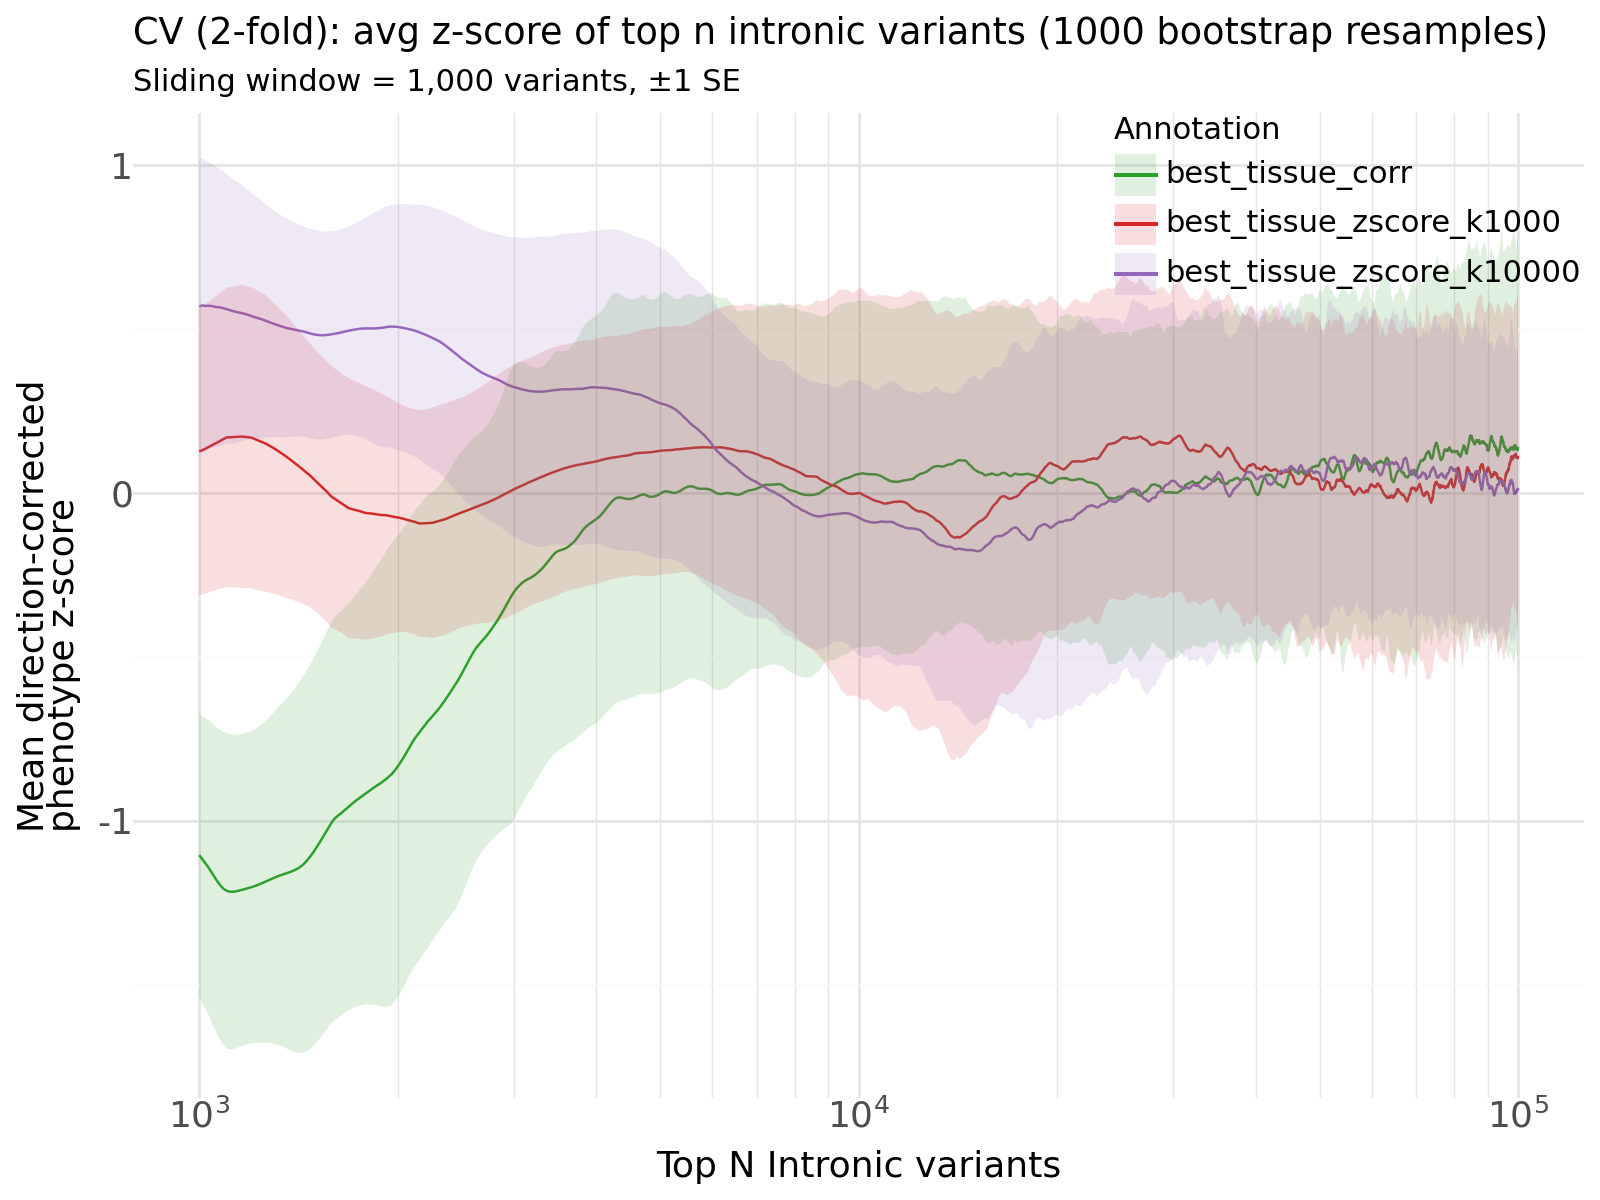

In [ ]:
# color_map is defined in the config cell (best-tissue + baseline colors)

plt_df_cv = (
    zscore_binned_cv
    .drop_nans()
    .filter(pl.col('bin_end') <= 100_000)
    .with_columns(log_bin_end=pl.col('bin_end').log10())
    .with_columns(color=pl.col('annotation').replace(color_map))
)

max_rank_cv = plt_df_cv['bin_end'].max()
min_rank_cv = plt_df_cv['bin_end'].min()
start_exp_cv = int(np.floor(np.log10(min_rank_cv)))
end_exp_cv   = int(np.ceil(np.log10(max_rank_cv)))
breaks_cv    = np.arange(start_exp_cv, end_exp_cv + 1)
labels_cv    = [f"$10^{{{int(b)}}}$" for b in breaks_cv]
minor_breaks_cv = [b for k in range(start_exp_cv, end_exp_cv) for b in [k + np.log10(m) for m in range(2, 10)] if min_rank_cv <= 10**b <= max_rank_cv]

color_dict_cv = dict(zip(plt_df_cv['annotation'], plt_df_cv['color']))

(
    ggplot(plt_df_cv, aes(x='log_bin_end', y='mean_zscore'))
    + geom_line(aes(color='annotation'))
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='annotation'), alpha=0.15)
    + scale_color_manual(values=color_dict_cv)
    + scale_fill_manual(values=color_dict_cv)
    + scale_x_continuous(breaks=breaks_cv, labels=labels_cv, minor_breaks=minor_breaks_cv)
    + labs(
        title=f"CV ({n_cv_folds}-fold): avg z-score of {x_label.lower()} ({n_boot_cv} bootstrap resamples)",
        subtitle=f"Sliding window = {window_size_cv:,} variants, ±{ci_factor_cv} SE",
        y="Mean direction-corrected\nphenotype z-score",
        x=x_label,
        color="Annotation", fill="Annotation",
    )
    + theme_minimal()
    + theme(
        figure_size=(8, 6),
        legend_position=(1, 1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        panel_grid_minor_x=element_line(color="#e5e5e5", size=0.5),
        legend_text=element_text(size=11),
        legend_title=element_text(size=11),
        plot_background=element_rect(fill="white", color="white"),
    )
)

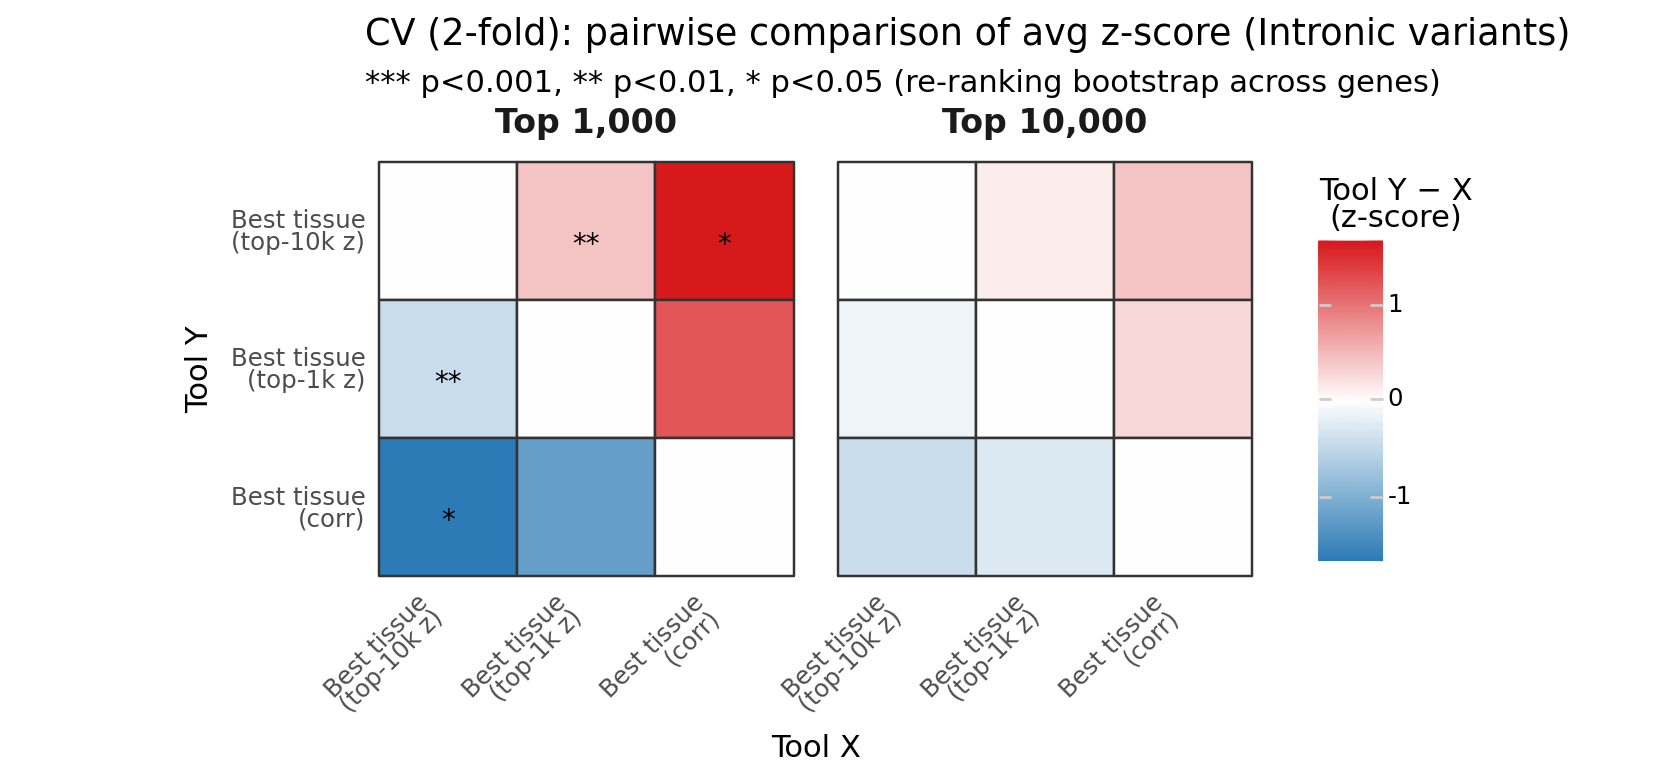

In [ ]:
# label_map is defined in the config cell (best-tissue + baseline labels)

rank_idx_cv = 1  # order by top 10_000
tool_means_cv = {ann: np.nanmean(boot_discrete_cv[ann][:, rank_idx_cv]) for ann in annotations_list_cv}
ordered_tools_cv = sorted(tool_means_cv.keys(), key=lambda x: tool_means_cv[x], reverse=True)
ordered_labels_cv = [label_map.get(t, t) for t in ordered_tools_cv]

heatmap_data_cv = []
for i, k_val in enumerate(target_k_cv):
    for ann_x, ann_y in itertools.product(ordered_tools_cv, repeat=2):
        label_x = label_map.get(ann_x, ann_x)
        label_y = label_map.get(ann_y, ann_y)
        if ann_x == ann_y:
            heatmap_data_cv.append({'Window': f"Top {k_val:,}", 'Window_Int': k_val,
                                    'Tool_X': label_x, 'Tool_Y': label_y, 'mean_diff': 0.0, 'sig': ''})
            continue
        boot_x = boot_discrete_cv[ann_x][:, i]
        boot_y = boot_discrete_cv[ann_y][:, i]
        diff = boot_y - boot_x
        mean_diff = np.nanmean(diff)
        p_val = 2 * min(np.nanmean(diff <= 0), np.nanmean(diff >= 0))
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
        heatmap_data_cv.append({'Window': f"Top {k_val:,}", 'Window_Int': k_val,
                                 'Tool_X': label_x, 'Tool_Y': label_y, 'mean_diff': mean_diff, 'sig': sig})

df_heat_cv = pd.DataFrame(heatmap_data_cv).sort_values('Window_Int')
df_heat_cv['Window'] = pd.Categorical(df_heat_cv['Window'], categories=df_heat_cv['Window'].unique(), ordered=True)
df_heat_cv['Tool_X'] = pd.Categorical(df_heat_cv['Tool_X'], categories=ordered_labels_cv, ordered=True)
df_heat_cv['Tool_Y'] = pd.Categorical(df_heat_cv['Tool_Y'], categories=ordered_labels_cv[::-1], ordered=True)

n_facets_cv = len(target_k_cv)
n_tools_cv  = len(ordered_tools_cv)

(
    ggplot(df_heat_cv, aes(x='Tool_X', y='Tool_Y', fill='mean_diff'))
    + geom_tile(color="#333333", size=0.5)
    + geom_text(aes(label='sig'), color="black", size=10, va='center', nudge_y=-0.1)
    + facet_wrap('~Window', ncol=n_facets_cv)
    + scale_fill_gradient2(low="#2C7BB6", mid="#FFFFFF", high="#D7191C", midpoint=0)
    + labs(
        title=f"CV ({n_cv_folds}-fold): pairwise comparison of avg z-score ({vc['x_label']} variants)",
        subtitle="*** p<0.001, ** p<0.01, * p<0.05 (re-ranking bootstrap across genes)",
        x="Tool X", y="Tool Y", fill="Tool Y − X\n(z-score)"
    )
    + theme_minimal()
    + theme(
        figure_size=(n_facets_cv * (n_tools_cv * 0.8 + 1.0) + 1.5, n_tools_cv * 0.8 + 1.5),
        aspect_ratio=1,
        axis_text_x=element_text(rotation=45, hjust=1),
        strip_text=element_text(size=12, face='bold'),
        panel_grid=element_blank(),
        plot_background=element_rect(fill="white", color="white"),
    )
)